# Hybrid IDS — Hierarchical 3-Tier Classifier

**Graduation project: H-IDS on CIC-IDS 2017 + CSE-CIC-IDS 2018**

This notebook trains a **3-tier hierarchical intrusion-detection model**:

1. **Stage 1 — Binary gate** (LightGBM): Benign vs Attack
2. **Stage 2 — Family classifier** (CatBoost, GPU): 6 broad attack families
3. **Stage 3 — Sub-attack classifiers** (XGBoost, one per family with multiple subtypes)

### Novelty vs prior work

* Uses the **Engelen / Rimmer / Joosen 2021 cleaned dataset** (≈20% of CIC-IDS-2017 flows mislabeled in the original release) — many published papers train on the raw, buggy version and overstate accuracy.
* **Family-grouped routing** collapses extreme-tail classes (Heartbleed = 3 samples, SQL-Injection = 10 samples) into their parent family at stage 2, then lets a smaller per-family model resolve subtypes at stage 3. Avoids the 42,000× class-weight blow-up that breaks single-model baselines.
* Per-stage **StandardScaler + manifest hash** for reproducible, version-pinned inference on the production FastAPI side.
* **Temporal Wednesday-afternoon hold-out** + **cross-dataset 2017 ↔ 2018 generalization study** — guards against the session-leakage bug Engelen flagged.

### Key references
* Engelen, Rimmer, Joosen (WTMC 2021). *Troubleshooting an Intrusion Detection Dataset: the CICIDS2017 Case Study.*
* Lanvin et al. (2022). *Errors in the CICIDS2017 dataset and the significant differences in detection performances they make.*
* arXiv:2403.13013 (2024). *Hierarchical Classification for Intrusion Detection System.*
* arXiv:2402.10974 (2024). *On the Cross-Dataset Generalization of Machine Learning for Network Intrusion Detection.*

## § 0 — Setup

Kaggle settings (right sidebar):
* **Accelerator: GPU T4 ×2** (or P100)
* **Internet: On**
* **Persistence: Files only**

In [2]:
!pip install -q lightgbm==4.6.0 catboost==1.2.8 xgboost==3.0.0 imbalanced-learn==0.13.0 shap==0.46.0 optuna==4.1.0
!python -c "import lightgbm, catboost, xgboost, imblearn, shap, optuna; print('ok')"

ok


In [3]:
import os, sys, json, random, hashlib, gc, time, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    balanced_accuracy_score,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

ART = Path('/kaggle/working/artifacts'); ART.mkdir(parents=True, exist_ok=True)
print('Artifacts dir:', ART)
print('sklearn:', __import__('sklearn').__version__)
print('lightgbm:', lgb.__version__, '| catboost:', cb.__version__, '| xgboost:', xgb.__version__)

Artifacts dir: /kaggle/working/artifacts
sklearn: 1.6.1
lightgbm: 4.6.0 | catboost: 1.2.8 | xgboost: 3.0.0


## § 1 — Dataset acquisition

Add data from the Kaggle right sidebar before running the notebook. **One dataset covers both years.**

### Primary recommendation (one-add, both years, cleaned)

| Search in sidebar | Slug | Notes |
|---|---|---|
| `improved cicids` | **`ernie55ernie/improved-cicids2017-and-csecicids2018`** | Cleaned + relabeled, deduplicated, covers 2017 *and* 2018 |

### Two-dataset fallbacks (if the primary is unavailable)

| Year | Cleaned option | Raw fallback (last resort) |
|---|---|---|
| 2017 | `ericanacletoribeiro/cicids2017-cleaned-and-preprocessed` | `chethuhn/network-intrusion-dataset` |
| 2018 | `ekkykharismadhany/csecicids2018-cleaned` | `solarmainframe/ids-intrusion-csv` |

### Why not the raw datasets?

`chethuhn/...` and `solarmainframe/...` are the unprocessed CICFlowMeter outputs. They contain:

* NaN/Inf in `Bwd PSH Flags` / `Bwd URG Flags` (CICFlowMeter bug — values always null)
* Documented mislabeling (~20% of 2017 flows, up to 41% of some 2018 classes — see Engelen et al. WTMC 2021)
* Cross-day duplicate flows in 2018 (Thursday's capfile mixed into Friday)
* ICMP packets mislabeled as UDP in 2018

The Engelen *gold-standard* cleaned dataset is **not on Kaggle** — it requires GitHub download + self-reprocessing with their fixed CICFlowMeter (~3 hours setup). `ernie55ernie/improved-...` is the closest pre-packaged Kaggle alternative.

The cell below **auto-detects** which slug you added, so no manual path edits are needed.

In [4]:
# Inspect what is mounted
for root, _, files in os.walk('/kaggle/input'):
    for f in files[:5]:
        p = Path(root) / f
        print(f'{p.stat().st_size/1e6:8.1f} MB  {p}')

   178.4 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/tuesday.csv
   207.9 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/monday.csv
   285.2 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/friday.csv
   291.3 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/wednesday.csv
   189.5 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/thursday.csv
  3689.8 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Friday-02-03-2018.csv
  3808.4 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Thursday-01-03-2018.csv
  3473.8 MB  /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Thursday-22-02-2018.csv
  39

In [5]:
from pathlib import Path

# Auto-detect which dataset slugs were mounted. Handles both:
#  (a) one combined dataset with both years inside (e.g. ernie55ernie/improved-...)
#  (b) two separate datasets — one per year
# In case (a), files are partitioned by year-marker in the filename or subfolder.

KAGGLE_INPUT = Path('/kaggle/input')

# Keywords identifying a directory that contains both years.
_HINTS_BOTH = [
    'improved-cicids', 'improved_cicids',
    'improved-cicids2017-and-csecicids2018',
    'improved_cicids2017_and_csecicids2018',
    'cicidscollection', 'cic-ids-collection', 'cicids-collection',
]

# Keywords for 2017-only directories.
_HINTS_17 = [
    'cicids2017', 'cicids-2017', 'cicids_2017', 'cic-ids-2017',
    'cicids2017_improved', 'cicids2017-improved',
    'improved-cicids2017', 'improved_cicids2017',
    'cleaned-cicids2017', 'cleaned_cicids2017',
    'network-intrusion', 'intrusion-detection',
]

# Keywords for 2018-only directories.
_HINTS_18 = [
    'cseicids2018', 'csecicids2018', 'cse-cic-ids2018', 'cic-ids-2018',
    'csecicids2018_improved', 'csecicids2018-improved',
    'improved-csecicids2018', 'improved_csecicids2018',
    'cicids-2018', 'cicids_2018', 'ids-intrusion', 'cse-cic',
    'ids2018', 'csecicids-2018',
]


def _matches(name: str, hints: list[str]) -> bool:
    n = name.lower()
    return any(h in n for h in hints)


def _find_dataset_dir(hints: list[str], *, recursive: bool = True) -> Path | None:
    """Find first directory under KAGGLE_INPUT whose name matches any hint.

    Walks the full tree (recursive=True) so it catches nested layouts like
    /kaggle/input/<parent>/CICIDS2017_improved/.
    """
    if not KAGGLE_INPUT.exists():
        return None
    iterator = KAGGLE_INPUT.rglob('*') if recursive else KAGGLE_INPUT.iterdir()
    for d in sorted(iterator):
        if d.is_dir() and _matches(d.name, hints):
            return d
    return None


def list_data_files(root: Path | None) -> list[Path]:
    if root is None or not root.exists():
        return []
    return sorted([*root.rglob('*.parquet'), *root.rglob('*.csv')])


def _is_within(child: Path | None, parent: Path | None) -> bool:
    if child is None or parent is None:
        return False
    try:
        child.relative_to(parent)
        return True
    except ValueError:
        return False


def _split_by_year(files: list[Path], root: Path | None = None) -> tuple[list[Path], list[Path]]:
    """Partition a combined-dataset file list into 2017 vs 2018.

    Matches against the path *relative to root* (i.e. the subfolder names
    inside the combined dataset) so a year in the parent dir name doesn't
    poison every match.
    """
    y17, y18 = [], []
    for f in files:
        # Use relative path so the combined-dir name itself is excluded.
        marker = str(f.relative_to(root) if root else f).lower()
        if '2017' in marker:
            y17.append(f)
        elif '2018' in marker:
            y18.append(f)
        else:
            # Last resort: treat ambiguous files as 2017 (the more popular year).
            y17.append(f)
    return y17, y18


# Try combined dataset first
COMBINED_DIR = _find_dataset_dir(_HINTS_BOTH)
CIC17_DIR = _find_dataset_dir(_HINTS_17)
CIC18_DIR = _find_dataset_dir(_HINTS_18)

# Avoid double-counting when a combined dataset also matches a year-hint,
# or when a year-dir is nested inside the combined-dir.
if COMBINED_DIR is not None:
    if CIC17_DIR == COMBINED_DIR or _is_within(CIC17_DIR, COMBINED_DIR):
        if CIC17_DIR == COMBINED_DIR:
            CIC17_DIR = None
    if CIC18_DIR == COMBINED_DIR or _is_within(CIC18_DIR, COMBINED_DIR):
        if CIC18_DIR == COMBINED_DIR:
            CIC18_DIR = None

# Resolution priority:
#  1. If specific year-dirs were found, use them (most precise).
#  2. Otherwise, if a combined dir was found, split its files by year.
if CIC17_DIR is not None or CIC18_DIR is not None:
    cic17_files = list_data_files(CIC17_DIR)
    cic18_files = list_data_files(CIC18_DIR)
    if COMBINED_DIR is not None:
        print(f'Combined dataset detected: {COMBINED_DIR.name}')
        print('  Using nested year-specific subfolders instead of splitting by filename.')
elif COMBINED_DIR is not None:
    combined_files = list_data_files(COMBINED_DIR)
    cic17_files, cic18_files = _split_by_year(combined_files, root=COMBINED_DIR)
    print(f'Combined dataset detected: {COMBINED_DIR.name}')
    print(f'  Split → 2017 files: {len(cic17_files)}, 2018 files: {len(cic18_files)}')
else:
    cic17_files, cic18_files = [], []


print('\nMounted input directories:')
for d in sorted(KAGGLE_INPUT.iterdir()):
    if d.is_dir():
        n = sum(1 for _ in d.rglob('*') if _.is_file())
        print(f'  {d.name}  ({n} files)')
        for sub in sorted(d.iterdir()):
            if sub.is_dir():
                ns = sum(1 for _ in sub.rglob('*') if _.is_file())
                print(f'    └─ {sub.name}  ({ns} files)')

print(f'\nResolved 2017 source: {CIC17_DIR or COMBINED_DIR}')
print(f'Resolved 2018 source: {CIC18_DIR or COMBINED_DIR}')

print(f'\nCIC-IDS-2017: {len(cic17_files)} files')
for f in cic17_files:
    print(' ', f.relative_to(KAGGLE_INPUT))
print(f'\nCSE-CIC-IDS-2018: {len(cic18_files)} files')
for f in cic18_files:
    print(' ', f.relative_to(KAGGLE_INPUT))

if not cic17_files:
    print('\n[WARNING] No 2017 files found. Add a CICIDS2017 dataset from the sidebar.')
if not cic18_files:
    print('\n[WARNING] No 2018 files found. Training will continue on 2017-only data; cross-dataset eval will be skipped.')

Combined dataset detected: improved-cicids2017-and-csecicids2018
  Split → 2017 files: 5, 2018 files: 10

Mounted input directories:
  datasets  (15 files)
    └─ ernie55ernie  (15 files)

Resolved 2017 source: /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018
Resolved 2018 source: /kaggle/input/datasets/ernie55ernie/improved-cicids2017-and-csecicids2018

CIC-IDS-2017: 5 files
  datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/friday.csv
  datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/monday.csv
  datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/thursday.csv
  datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/tuesday.csv
  datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CICIDS2017_improved/wednesday.csv

CSE-CIC-IDS-2018: 10 files
  datasets/ernie55ernie/improved-cicids2017-and-csecicids2018/CSECICIDS2018_improved/Friday-02-03

In [6]:
# Canonical 70 features expected by the production app. Duplicated here (also re-defined
# in § 2) so the Parquet conversion can filter columns BEFORE the OOM-prone full load.
SELECTED_FEATURES = [
    'Dst Port', 'Protocol', 'Flow Duration', 'Fwd Packet Length Max', 'Fwd Packet Length Min',
    'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Max', 'Packet Length Min',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Fwd Header Length',
    'Bwd Header Length', 'Fwd Seg Size Min', 'Fwd Act Data Pkts', 'Flow IAT Mean', 'Flow IAT Max',
    'Flow IAT Min', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg',
    'Bwd Segment Size Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
    'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'FWD Init Win Bytes',
    'Bwd Init Win Bytes', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
    'Idle Std', 'Idle Max', 'Idle Min',
]
assert len(SELECTED_FEATURES) == 70

# Source-name → canonical alias map (also re-defined in § 2).
COL_ALIASES = {
    'Destination Port': 'Dst Port', 'Init Fwd Win Bytes': 'FWD Init Win Bytes',
    'Init Bwd Win Bytes': 'Bwd Init Win Bytes', 'Init_Win_bytes_forward': 'FWD Init Win Bytes',
    'Init_Win_bytes_backward': 'Bwd Init Win Bytes', 'Total Fwd Packets': 'Total Fwd Packet',
    'Total Backward Packets': 'Total Bwd packets', 'Total Length of Bwd Packets': 'Total Length of Bwd Packet',
    'Fwd Header Length.1': 'Fwd Header Length', 'min_seg_size_forward': 'Fwd Seg Size Min',
    'act_data_pkt_fwd': 'Fwd Act Data Pkts', 'Avg Fwd Segment Size': 'Fwd Segment Size Avg',
    'Avg Bwd Segment Size': 'Bwd Segment Size Avg', 'Fwd Avg Bytes/Bulk': 'Fwd Bytes/Bulk Avg',
    'Fwd Avg Packets/Bulk': 'Fwd Packet/Bulk Avg', 'Fwd Avg Bulk Rate': 'Fwd Bulk Rate Avg',
    'Bwd Avg Bytes/Bulk': 'Bwd Bytes/Bulk Avg', 'Bwd Avg Packets/Bulk': 'Bwd Packet/Bulk Avg',
    'Bwd Avg Bulk Rate': 'Bwd Bulk Rate Avg', 'CWE Flag Count': 'CWR Flag Count',
    'Max Packet Length': 'Packet Length Max', 'Min Packet Length': 'Packet Length Min',
}

PARQUET_DIR = Path('/kaggle/working/parquet_cache')
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
_SELECTED_SET = set(SELECTED_FEATURES)


def _canonical(name: str) -> str:
    """Strip and alias-rename a single source column to its canonical CIC-IDS form."""
    n = name.strip()
    return COL_ALIASES.get(n, n)


def csv_to_parquet(path: Path, out_dir: Path, chunk_size: int = 200_000) -> Path:
    """Stream-convert a CIC-IDS CSV to a column-filtered, float32 parquet file.

    Reads the CSV in `chunk_size` row chunks, keeps only columns that map to
    `SELECTED_FEATURES` (after alias normalization) plus the Label, coerces
    numerics to float32, and writes snappy-compressed parquet.
    """
    out_path = out_dir / (path.stem + '.parquet')
    if out_path.exists():
        return out_path  # idempotent — skip already-converted files

    # Peek header to figure out which source-name columns we need to keep.
    header = pd.read_csv(path, nrows=0).columns.tolist()
    rename_map = {c: _canonical(c) for c in header}
    label_src = next((c for c, canon in rename_map.items()
                      if canon.strip().lower() == 'label'), None)
    keep_src = [c for c, canon in rename_map.items() if canon in _SELECTED_SET]
    usecols = keep_src + ([label_src] if label_src else [])
    if not keep_src:
        print(f'  [skip] {path.name}: no matching feature columns')
        return out_path

    chunks = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunk_size,
                             low_memory=False, on_bad_lines='skip'):
        chunk.rename(columns=rename_map, inplace=True)
        chunk.columns = chunk.columns.str.strip()
        # Coerce numerics + downcast (handles 'Infinity'/'NaN' string values gracefully)
        for c in chunk.columns:
            if c.strip().lower() == 'label':
                continue
            chunk[c] = pd.to_numeric(chunk[c], errors='coerce').astype('float32')
        chunks.append(chunk)

    df = pd.concat(chunks, ignore_index=True)
    df.to_parquet(out_path, index=False, compression='snappy')
    rows, mb = len(df), out_path.stat().st_size / 1e6
    del df, chunks
    gc.collect()
    print(f'  {path.name:<60s} → {rows:>10,} rows, {mb:>6.1f} MB parquet')
    return out_path


csv_inputs = [f for f in (cic17_files + cic18_files) if f.suffix == '.csv']
print(f'Converting {len(csv_inputs)} CSV files to parquet cache at {PARQUET_DIR} ...')
for f in csv_inputs:
    csv_to_parquet(f, PARQUET_DIR)
print('\nParquet cache ready.')
print('Cached files:')
for p in sorted(PARQUET_DIR.iterdir()):
    print(f'  {p.stat().st_size/1e6:>6.1f} MB  {p.name}')

Converting 15 CSV files to parquet cache at /kaggle/working/parquet_cache ...

Parquet cache ready.
Cached files:
   645.4 MB  Friday-02-03-2018.parquet
   666.3 MB  Friday-16-02-2018.parquet
   613.8 MB  Friday-23-02-2018.parquet
   677.0 MB  Thursday-01-03-2018.parquet
   530.6 MB  Thursday-15-02-2018.parquet
   624.9 MB  Thursday-22-02-2018.parquet
   596.2 MB  Tuesday-20-02-2018.parquet
   560.0 MB  Wednesday-14-02-2018.parquet
   654.7 MB  Wednesday-21-02-2018.parquet
   680.5 MB  Wednesday-28-02-2018.parquet
    51.5 MB  friday.parquet
    40.0 MB  monday.parquet
    34.7 MB  thursday.parquet
    34.4 MB  tuesday.parquet
    50.1 MB  wednesday.parquet


In [ ]:
import gc
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

PARQUET_DIR = Path('/kaggle/working/parquet_cache')
COMBINED_DIR = Path('/kaggle/working/combined')
COMBINED_DIR.mkdir(exist_ok=True)

CIC17_NAMES = {'friday', 'monday', 'thursday', 'tuesday', 'wednesday'}
cic17_files = sorted(p for p in PARQUET_DIR.glob('*.parquet') if p.stem.lower() in CIC17_NAMES)
cic18_files = sorted(p for p in PARQUET_DIR.glob('*.parquet') if p.stem not in CIC17_NAMES)

print(f'CIC2017 → {len(cic17_files)} parquet files')
print(f'CIC2018 → {len(cic18_files)} parquet files')
assert len(cic17_files) == 5 and len(cic18_files) == 10, 'parquet cache incomplete'

# CIC2017 uses different names for a few columns — normalize to CIC2018 vocabulary.
RENAME_2017_TO_2018 = {
    'Destination Port': 'Dst Port',
    'Total Length of Fwd Packets': 'Fwd Packets Length Total',
    'Total Length of Bwd Packets': 'Bwd Packets Length Total',
    'Fwd Packet Length Max':  'Fwd Packet Length Max',
    'Max Packet Length': 'Packet Length Max',
    'Min Packet Length': 'Packet Length Min',
    'Average Packet Size': 'Average Packet Size',
    'Avg Fwd Segment Size': 'Fwd Segment Size Avg',
    'Avg Bwd Segment Size': 'Bwd Segment Size Avg',
    'Fwd Avg Bytes/Bulk':  'Fwd Bytes/Bulk Avg',
    'Fwd Avg Packets/Bulk':'Fwd Packet/Bulk Avg',
    'Fwd Avg Bulk Rate':   'Fwd Bulk Rate Avg',
    'Bwd Avg Bytes/Bulk':  'Bwd Bytes/Bulk Avg',
    'Bwd Avg Packets/Bulk':'Bwd Packet/Bulk Avg',
    'Bwd Avg Bulk Rate':   'Bwd Bulk Rate Avg',
    'Init_Win_bytes_forward':  'FWD Init Win Bytes',
    'Init_Win_bytes_backward': 'Bwd Init Win Bytes',
    'act_data_pkt_fwd': 'Fwd Act Data Pkts',
    'min_seg_size_forward': 'Fwd Seg Size Min',
}

def shrink(df: pd.DataFrame) -> pd.DataFrame:
    # Downcast floats: float64 -> float32
    f_cols = df.select_dtypes(include=['float64']).columns
    for c in f_cols:
        df[c] = pd.to_numeric(df[c], downcast='float')
    # Downcast ints: int64 -> smallest signed int
    i_cols = df.select_dtypes(include=['int64']).columns
    for c in i_cols:
        df[c] = pd.to_numeric(df[c], downcast='integer')
    # Low-cardinality object -> category (Label, protocol, etc.)
    for c in df.select_dtypes(include=['object']).columns:
        if df[c].nunique(dropna=False) / max(len(df), 1) < 0.5:
            df[c] = df[c].astype('category')
    return df

def read_any(path: Path) -> pd.DataFrame:
    fmt = 'parquet' if path.suffix == '.parquet' else 'csv'
    print(f'  reading {path.name:40s}  [{fmt}]  from {path.parent}')
    df = pd.read_parquet(path) if path.suffix == '.parquet' else pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    return shrink(df)

def load_dataset(files, source_tag: str) -> pd.DataFrame:
    out_path = COMBINED_DIR / f'{source_tag}.parquet'
    writer = None
    total_rows = 0

    for f in files:
        df = read_any(f)
        if source_tag == 'CIC2017':
            df = df.rename(columns=RENAME_2017_TO_2018)
        df['__source'] = source_tag
        df['__file']   = f.name
        # Keep these as small strings (pyarrow handles dictionaries on write)
        df['__source'] = df['__source'].astype('category')
        df['__file']   = df['__file'].astype('category')

        table = pa.Table.from_pandas(df, preserve_index=False)
        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema, compression='snappy')
        else:
            # Align schema in case dtypes drift slightly between files
            table = table.cast(writer.schema, safe=False)
        writer.write_table(table)

        total_rows += len(df)
        print(f'  wrote  {f.name:40s}  {len(df):>10,} rows  (running total: {total_rows:,})')
        del df, table
        gc.collect()

    writer.close()
    size_gb = out_path.stat().st_size / 1e9
    print(f'{source_tag}: wrote {total_rows:,} rows to {out_path}  ({size_gb:.2f} GB on disk)')

    # Read back as one allocation
    out = pd.read_parquet(out_path)
    print(f'{source_tag}: loaded into RAM  '
          f'({out.memory_usage(deep=True).sum() / 1e9:.2f} GB)')
    return out

df17 = load_dataset(cic17_files, 'CIC2017')
gc.collect()
df18 = load_dataset(cic18_files, 'CIC2018')
gc.collect()

print('\nSample columns 2017:', df17.columns[:6].tolist(), '...')
print('Sample columns 2018:', df18.columns[:6].tolist(), '...')

CIC2017 → 5 parquet files
CIC2018 → 10 parquet files
  reading friday.parquet                            [parquet]  from /kaggle/working/parquet_cache
  wrote  friday.parquet                               547,557 rows  (running total: 547,557)
  reading monday.parquet                            [parquet]  from /kaggle/working/parquet_cache
  wrote  monday.parquet                               371,624 rows  (running total: 919,181)
  reading thursday.parquet                          [parquet]  from /kaggle/working/parquet_cache
  wrote  thursday.parquet                             362,076 rows  (running total: 1,281,257)
  reading tuesday.parquet                           [parquet]  from /kaggle/working/parquet_cache
  wrote  tuesday.parquet                              322,078 rows  (running total: 1,603,335)
  reading wednesday.parquet                         [parquet]  from /kaggle/working/parquet_cache
  wrote  wednesday.parquet                            496,641 rows  (running tota

In [1]:
import shutil
shutil.rmtree('/kaggle/working/combined', ignore_errors=True)

## § 2 — Schema alignment + cleanup

CIC-2017 and CIC-2018 use slightly different column casing. We normalize to the **CIC-IDS canonical names** used by the production FastAPI app ([app/models/selected_features.json](app/models/selected_features.json) on the project repo).

In [ ]:
# Canonical 70 features expected by the production app (post-leakage-drop).
SELECTED_FEATURES = [
    'Dst Port', 'Protocol', 'Flow Duration', 'Fwd Packet Length Max', 'Fwd Packet Length Min',
    'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Max', 'Packet Length Min',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Fwd Header Length',
    'Bwd Header Length', 'Fwd Seg Size Min', 'Fwd Act Data Pkts', 'Flow IAT Mean', 'Flow IAT Max',
    'Flow IAT Min', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg',
    'Bwd Segment Size Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
    'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'FWD Init Win Bytes',
    'Bwd Init Win Bytes', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
    'Idle Std', 'Idle Max', 'Idle Min',
]
assert len(SELECTED_FEATURES) == 70

# Map any known alternative spellings seen in dhoogla / raw releases.
COL_ALIASES = {
    'Destination Port': 'Dst Port', 'Init Fwd Win Bytes': 'FWD Init Win Bytes',
    'Init Bwd Win Bytes': 'Bwd Init Win Bytes', 'Init_Win_bytes_forward': 'FWD Init Win Bytes',
    'Init_Win_bytes_backward': 'Bwd Init Win Bytes', 'Total Fwd Packets': 'Total Fwd Packet',
    'Total Backward Packets': 'Total Bwd packets', 'Total Length of Bwd Packets': 'Total Length of Bwd Packet',
    'Fwd Header Length.1': 'Fwd Header Length', 'min_seg_size_forward': 'Fwd Seg Size Min',
    'act_data_pkt_fwd': 'Fwd Act Data Pkts', 'Avg Fwd Segment Size': 'Fwd Segment Size Avg',
    'Avg Bwd Segment Size': 'Bwd Segment Size Avg', 'Fwd Avg Bytes/Bulk': 'Fwd Bytes/Bulk Avg',
    'Fwd Avg Packets/Bulk': 'Fwd Packet/Bulk Avg', 'Fwd Avg Bulk Rate': 'Fwd Bulk Rate Avg',
    'Bwd Avg Bytes/Bulk': 'Bwd Bytes/Bulk Avg', 'Bwd Avg Packets/Bulk': 'Bwd Packet/Bulk Avg',
    'Bwd Avg Bulk Rate': 'Bwd Bulk Rate Avg', 'CWE Flag Count': 'CWR Flag Count',
    'Max Packet Length': 'Packet Length Max', 'Min Packet Length': 'Packet Length Min',
}

def normalize_columns(df):
    df = df.rename(columns=COL_ALIASES)
    df.columns = df.columns.str.strip()
    return df

df17 = normalize_columns(df17)
df18 = normalize_columns(df18)

# Sanity-check feature coverage
missing17 = [c for c in SELECTED_FEATURES if c not in df17.columns]
missing18 = [c for c in SELECTED_FEATURES if c not in df18.columns]
print('Missing in 2017:', missing17)
print('Missing in 2018:', missing18)

In [ ]:
# Standardize label column name & values across datasets
LABEL_NORMALIZE = {
    'BENIGN': 'Benign', 'Benign': 'Benign',
    'DoS Hulk': 'DoS-Hulk', 'DoS GoldenEye': 'DoS-GoldenEye',
    'DoS slowloris': 'DoS-Slowloris', 'DoS Slowloris': 'DoS-Slowloris',
    'DoS Slowhttptest': 'DoS-SlowHTTPTest', 'DoS slowhttptest': 'DoS-SlowHTTPTest',
    'DDoS': 'DDoS', 'DDOS attack-HOIC': 'DDoS', 'DDOS attack-LOIC-UDP': 'DDoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'PortScan': 'PortScan', 'Bot': 'Bot', 'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed',
    'FTP-Patator': 'FTP-BruteForce', 'FTP-BruteForce': 'FTP-BruteForce',
    'SSH-Patator': 'SSH-BruteForce', 'SSH-Bruteforce': 'SSH-BruteForce',
    'Web Attack - Brute Force': 'BruteForce-Web', 'Brute Force -Web': 'BruteForce-Web',
    'Brute Force -XSS': 'BruteForce-XSS', 'Web Attack - XSS': 'BruteForce-XSS',
    'SQL Injection': 'SQL-Injection', 'Web Attack - Sql Injection': 'SQL-Injection',
    'SQL-Injection': 'SQL-Injection',
}

for d in (df17, df18):
    if 'Label' in d.columns:
        d['Label'] = d['Label'].astype(str).str.strip().replace(LABEL_NORMALIZE)

print('2017 label counts:'); print(df17['Label'].value_counts())
print('\n2018 label counts:'); print(df18['Label'].value_counts())

In [ ]:
# Combine + cleanup. Keep __source so we can do cross-dataset eval later.
common_cols = [c for c in SELECTED_FEATURES if c in df17.columns and c in df18.columns]
keep = common_cols + ['Label', '__source']
df = pd.concat([df17[keep], df18[keep]], ignore_index=True)
print('Combined:', df.shape)

# Replace ±inf, drop NaNs, drop duplicates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
df.drop_duplicates(subset=common_cols, inplace=True)
print(f'After NaN+dedup: {len(df):,} rows (dropped {before-len(df):,})')

# Free memory
del df17, df18, frames if 'frames' in dir() else None
gc.collect()

# Downcast for memory
for c in df.columns:
    if df[c].dtype == 'float64': df[c] = df[c].astype('float32')
    elif df[c].dtype == 'int64': df[c] = df[c].astype('int32')

print('\nFinal label distribution:')
print(df['Label'].value_counts())

In [7]:
# =============================================================================
# § 1b + § 2 — OOM-safe stream-clean pipeline
#
# CIC2018 raw = 63 M rows × 70 features × 4 bytes ≈ 18 GB in RAM.
# Kaggle has ~13 GB.  Solution:
#   1. Clean each parquet_cache/ file ONE AT A TIME (~6 M rows, ~1.5 GB peak).
#   2. Write slim cleaned partitions to disk.
#   3. Read back with benign-cap: keep ALL attack rows, subsample benign per
#      source so the final concat fits comfortably in RAM.
#   4. Cross-file dedup.
#
# Produces `df` (common_cols + Label + __source) — same contract as before.
# =============================================================================
import gc, numpy as np, pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

PARQUET_DIR = Path('/kaggle/working/parquet_cache')
CLEAN_DIR   = Path('/kaggle/working/clean_partitions')
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

CIC17_NAMES = {'friday', 'monday', 'thursday', 'tuesday', 'wednesday'}
cic17_pq = sorted(p for p in PARQUET_DIR.glob('*.parquet') if p.stem.lower() in CIC17_NAMES)
cic18_pq = sorted(p for p in PARQUET_DIR.glob('*.parquet') if p.stem.lower() not in CIC17_NAMES)
print(f'parquet_cache → CIC2017: {len(cic17_pq)} files, CIC2018: {len(cic18_pq)} files')

# ── Tunable: max benign rows to keep PER SOURCE ────────────────────────────
# CIC2017 is small (~2 M total) → keep everything.
# CIC2018 is huge (~63 M, mostly benign) → cap benign to save RAM.
# All attack rows are ALWAYS kept regardless of this cap.
# Adjust if you have more/less RAM.
MAX_BENIGN = {
    'CIC2017': None,        # keep all
    'CIC2018': 2_000_000,   # cap benign at 2 M (attack rows untouched)
}

# ── Column aliases ───────────────────────────────────────────────────────────
SELECTED_FEATURES = [
    'Dst Port', 'Protocol', 'Flow Duration', 'Fwd Packet Length Max', 'Fwd Packet Length Min',
    'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Max', 'Packet Length Min',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Fwd Header Length',
    'Bwd Header Length', 'Fwd Seg Size Min', 'Fwd Act Data Pkts', 'Flow IAT Mean', 'Flow IAT Max',
    'Flow IAT Min', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Std',
    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg',
    'Bwd Segment Size Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg',
    'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'FWD Init Win Bytes',
    'Bwd Init Win Bytes', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean',
    'Idle Std', 'Idle Max', 'Idle Min',
]
SEED = 42
RENAME_2017_TO_2018 = {
    'Destination Port': 'Dst Port',
    'Total Length of Fwd Packets': 'Fwd Packets Length Total',
    'Total Length of Bwd Packets': 'Bwd Packets Length Total',
    'Max Packet Length': 'Packet Length Max',
    'Min Packet Length': 'Packet Length Min',
    'Avg Fwd Segment Size': 'Fwd Segment Size Avg',
    'Avg Bwd Segment Size': 'Bwd Segment Size Avg',
    'Fwd Avg Bytes/Bulk':  'Fwd Bytes/Bulk Avg',
    'Fwd Avg Packets/Bulk':'Fwd Packet/Bulk Avg',
    'Fwd Avg Bulk Rate':   'Fwd Bulk Rate Avg',
    'Bwd Avg Bytes/Bulk':  'Bwd Bytes/Bulk Avg',
    'Bwd Avg Packets/Bulk':'Bwd Packet/Bulk Avg',
    'Bwd Avg Bulk Rate':   'Bwd Bulk Rate Avg',
    'Init_Win_bytes_forward':  'FWD Init Win Bytes',
    'Init_Win_bytes_backward': 'Bwd Init Win Bytes',
    'act_data_pkt_fwd': 'Fwd Act Data Pkts',
    'min_seg_size_forward': 'Fwd Seg Size Min',
}

COL_ALIASES = {
    'Destination Port': 'Dst Port', 'Init Fwd Win Bytes': 'FWD Init Win Bytes',
    'Init Bwd Win Bytes': 'Bwd Init Win Bytes', 'Init_Win_bytes_forward': 'FWD Init Win Bytes',
    'Init_Win_bytes_backward': 'Bwd Init Win Bytes', 'Total Fwd Packets': 'Total Fwd Packet',
    'Total Backward Packets': 'Total Bwd packets',
    'Total Length of Bwd Packets': 'Total Length of Bwd Packet',
    'Fwd Header Length.1': 'Fwd Header Length', 'min_seg_size_forward': 'Fwd Seg Size Min',
    'act_data_pkt_fwd': 'Fwd Act Data Pkts', 'Avg Fwd Segment Size': 'Fwd Segment Size Avg',
    'Avg Bwd Segment Size': 'Bwd Segment Size Avg', 'Fwd Avg Bytes/Bulk': 'Fwd Bytes/Bulk Avg',
    'Fwd Avg Packets/Bulk': 'Fwd Packet/Bulk Avg', 'Fwd Avg Bulk Rate': 'Fwd Bulk Rate Avg',
    'Bwd Avg Bytes/Bulk': 'Bwd Bytes/Bulk Avg', 'Bwd Avg Packets/Bulk': 'Bwd Packet/Bulk Avg',
    'Bwd Avg Bulk Rate': 'Bwd Bulk Rate Avg', 'CWE Flag Count': 'CWR Flag Count',
    'Max Packet Length': 'Packet Length Max', 'Min Packet Length': 'Packet Length Min',
}

LABEL_NORMALIZE = {
    'BENIGN': 'Benign', 'Benign': 'Benign',
    'DoS Hulk': 'DoS-Hulk', 'DoS GoldenEye': 'DoS-GoldenEye',
    'DoS slowloris': 'DoS-Slowloris', 'DoS Slowloris': 'DoS-Slowloris',
    'DoS Slowhttptest': 'DoS-SlowHTTPTest', 'DoS slowhttptest': 'DoS-SlowHTTPTest',
    'DDoS': 'DDoS', 'DDOS attack-HOIC': 'DDoS', 'DDOS attack-LOIC-UDP': 'DDoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'PortScan': 'PortScan', 'Bot': 'Bot', 'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed',
    'FTP-Patator': 'FTP-BruteForce', 'FTP-BruteForce': 'FTP-BruteForce',
    'SSH-Patator': 'SSH-BruteForce', 'SSH-Bruteforce': 'SSH-BruteForce',
    'Web Attack - Brute Force': 'BruteForce-Web', 'Brute Force -Web': 'BruteForce-Web',
    'Brute Force -XSS': 'BruteForce-XSS', 'Web Attack - XSS': 'BruteForce-XSS',
    'SQL Injection': 'SQL-Injection', 'Web Attack - Sql Injection': 'SQL-Injection',
    'SQL-Injection': 'SQL-Injection',
}

_SELECTED_SET = set(SELECTED_FEATURES)

# ── Per-file cleaning ────────────────────────────────────────────────────────
def clean_one(path: Path, source_tag: str) -> Path:
    """Clean a single parquet file and write the result to CLEAN_DIR."""
    out = CLEAN_DIR / f'{source_tag}__{path.stem}.parquet'
    if out.exists():
        n = pq.read_metadata(out).num_rows
        print(f'  [cached]  {path.name:40s}  {n:>10,} rows')
        return out

    df = pd.read_parquet(path)
    df.columns = df.columns.str.strip()

    # Column renames
    if source_tag == 'CIC2017':
        df.rename(columns=RENAME_2017_TO_2018, inplace=True)
    df.rename(columns=COL_ALIASES, inplace=True)
    df.columns = df.columns.str.strip()

    # Select features
    keep_f = [c for c in SELECTED_FEATURES if c in df.columns]
    keep   = keep_f + (['Label'] if 'Label' in df.columns else [])
    df = df[keep].copy()

    # Numerics → float32, kill inf/NaN
    for c in keep_f:
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('float32')
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    before = len(df)
    df.dropna(inplace=True)

    # Label normalization
    if 'Label' in df.columns:
        df['Label'] = df['Label'].astype(str).str.strip().replace(LABEL_NORMALIZE)

    # Source tag
    df['__source'] = source_tag

    df.to_parquet(out, index=False, compression='snappy')
    print(f'  cleaned   {path.name:40s}  {len(df):>10,} rows  '
          f'(dropped {before-len(df):,})  {out.stat().st_size/1e6:>6.1f} MB')
    del df; gc.collect()
    return out


print('── Cleaning CIC2017 partitions ──')
clean17 = [clean_one(f, 'CIC2017') for f in cic17_pq]
print('── Cleaning CIC2018 partitions ──')
clean18 = [clean_one(f, 'CIC2018') for f in cic18_pq]

# ── Determine common feature columns ────────────────────────────────────────
all_schemas = [set(pq.read_schema(p).names) for p in clean17 + clean18]
common_cols = [c for c in SELECTED_FEATURES if all(c in s for s in all_schemas)]
print(f'\nCommon features: {len(common_cols)}/70')
keep_cols = common_cols + ['Label', '__source']

# ── Read back with benign-cap ────────────────────────────────────────────────
def load_capped(parts: list[Path], source_tag: str) -> pd.DataFrame:
    """Read cleaned partitions, keeping all attack rows but capping benign."""
    cap = MAX_BENIGN.get(source_tag)
    frames = []
    benign_so_far = 0
    for p in parts:
        chunk = pd.read_parquet(p, columns=keep_cols)

        if cap is not None:
            is_benign = chunk['Label'] == 'Benign'
            attack = chunk[~is_benign]
            benign = chunk[is_benign]
            remaining = max(0, cap - benign_so_far)
            if remaining < len(benign):
                benign = benign.sample(n=remaining, random_state=SEED)
            benign_so_far += len(benign)
            chunk = pd.concat([attack, benign], ignore_index=True)

        frames.append(chunk)
        print(f'  loaded {p.stem:55s}  {len(chunk):>10,} rows')
        del chunk; gc.collect()

    out = pd.concat(frames, ignore_index=True)
    del frames; gc.collect()
    print(f'  {source_tag} total: {len(out):,} rows  '
          f'(RAM: {out.memory_usage(deep=True).sum()/1e9:.2f} GB)')
    return out

print('\n── Loading CIC2017 (all rows) ──')
df17 = load_capped(clean17, 'CIC2017')
print('\n── Loading CIC2018 (benign capped) ──')
df18 = load_capped(clean18, 'CIC2018')

# ── Combine + cross-file dedup ───────────────────────────────────────────────
df = pd.concat([df17, df18], ignore_index=True)
del df17, df18; gc.collect()
print(f'\nCombined: {df.shape}')

before = len(df)
df.drop_duplicates(subset=common_cols, inplace=True)
print(f'After cross-file dedup: {len(df):,} rows (dropped {before-len(df):,})')

# Final downcast
for c in df.columns:
    if df[c].dtype == 'float64': df[c] = df[c].astype('float32')
    elif df[c].dtype == 'int64': df[c] = df[c].astype('int32')

print(f'RAM: {df.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'\n2017 labels:\n{df.loc[df.__source=="CIC2017","Label"].value_counts()}')
print(f'\n2018 labels:\n{df.loc[df.__source=="CIC2018","Label"].value_counts()}')
print(f'\nFinal label distribution:\n{df["Label"].value_counts()}')
print(f'\nMissing features: {[c for c in SELECTED_FEATURES if c not in df.columns]}')


parquet_cache → CIC2017: 5 files, CIC2018: 10 files
── Cleaning CIC2017 partitions ──
  cleaned   friday.parquet                               547,557 rows  (dropped 0)    51.5 MB
  cleaned   monday.parquet                               371,624 rows  (dropped 0)    40.0 MB
  cleaned   thursday.parquet                             362,076 rows  (dropped 0)    34.7 MB
  cleaned   tuesday.parquet                              322,078 rows  (dropped 0)    34.4 MB
  cleaned   wednesday.parquet                            496,641 rows  (dropped 0)    50.1 MB
── Cleaning CIC2018 partitions ──
  cleaned   Friday-02-03-2018.parquet                  6,311,371 rows  (dropped 0)   645.4 MB
  cleaned   Friday-16-02-2018.parquet                  7,390,266 rows  (dropped 0)   666.3 MB
  cleaned   Friday-23-02-2018.parquet                  5,976,481 rows  (dropped 0)   613.8 MB
  cleaned   Thursday-01-03-2018.parquet                6,551,401 rows  (dropped 0)   677.0 MB
  cleaned   Thursday-15-02-2018.pa

In [9]:
# =============================================================================
# § 2b — Fix labels from ernie55ernie improved dataset
# =============================================================================

LABEL_FIX = {
    # ── DDoS variants (mixed-case prefix as used by this dataset) ──
    'DDoS-HOIC':                  'DDoS',
    'DDoS-LOIC-HTTP':             'DDoS',
    'DDoS-LOIC-UDP':              'DDoS',
    'DDoS-LOIC-UDP - Attempted':  'DDoS',
    'DDOS-HOIC':                  'DDoS',
    'DDOS-LOIC-HTTP':             'DDoS',
    'DDOS-LOIC-UDP':              'DDoS',
    'DDOS-LOIC-UDP - Attempted':  'DDoS',

    # ── DoS "Attempted" variants ──
    'DoS GoldenEye - Attempted':       'DoS-GoldenEye',
    'DoS Slowloris - Attempted':       'DoS-Slowloris',
    'DoS Slowhttptest - Attempted':    'DoS-SlowHTTPTest',
    'DoS Hulk - Attempted':            'DoS-Hulk',

    # ── Botnet → Bot ──
    'Botnet':                     'Bot',
    'Botnet Ares':                'Bot',
    'Botnet - Attempted':         'Bot',
    'Botnet Ares - Attempted':    'Bot',

    # ── PortScan (case fix + infiltration-scan) ──
    'Portscan':                        'PortScan',
    'Infiltration - NMAP Portscan':    'PortScan',
    'Infiltration - Portscan':         'PortScan',

    # ── Infiltration sub-categories ──
    'Infiltration - Attempted':                       'Infiltration',
    'Infiltration - Communication Victim Attacker':   'Infiltration',
    'Infiltration - Dropbox Download':                'Infiltration',
    'Infiltration - Dropbox Download - Attempted':    'Infiltration',

    # ── BruteForce "Attempted" variants ──
    'Web Attack - Brute Force - Attempted':   'BruteForce-Web',
    'Web Attack - XSS - Attempted':           'BruteForce-XSS',
    'FTP-BruteForce - Attempted':             'FTP-BruteForce',
    'FTP-Patator - Attempted':                'FTP-BruteForce',
    'SSH-Patator - Attempted':                'SSH-BruteForce',

    # ── SQL Injection variants ──
    'Web Attack - SQL':                        'SQL-Injection',
    'Web Attack - SQL - Attempted':            'SQL-Injection',
    'Web Attack - SQL Injection':              'SQL-Injection',
    'Web Attack - SQL Injection - Attempted':  'SQL-Injection',
}

df['Label'] = df['Label'].replace(LABEL_FIX)

# Verify all labels now map to the 15 expected canonical names
EXPECTED = {
    'Benign', 'DoS-Hulk', 'DoS-GoldenEye', 'DoS-Slowloris', 'DoS-SlowHTTPTest',
    'DDoS', 'PortScan', 'FTP-BruteForce', 'SSH-BruteForce',
    'BruteForce-Web', 'BruteForce-XSS', 'SQL-Injection',
    'Bot', 'Infiltration', 'Heartbleed',
}
actual = set(df['Label'].unique())
unmapped = actual - EXPECTED
assert len(unmapped) == 0, f'Still unmapped labels: {unmapped}'

print('✅ All labels normalized to 15 canonical classes.')
print(df['Label'].value_counts())


✅ All labels normalized to 15 canonical classes.
Label
Benign              3108674
DoS-Hulk            1962240
DDoS                1469543
PortScan             177476
Bot                  144931
SSH-BruteForce        97185
DoS-GoldenEye         34505
DoS-Slowloris         14838
DoS-SlowHTTPTest       5091
FTP-BruteForce         4041
BruteForce-Web         1633
BruteForce-XSS          790
Infiltration            398
SQL-Injection            71
Heartbleed               11
Name: count, dtype: int64


## § 3 — Family mapping

The hierarchical novelty: collapse 14 attack labels into **6 attack families** for stage 2, and only resolve subtypes in stage 3.  This is what handles the long-tail (Heartbleed, SQL-Injection, BruteForce-XSS) without exploding class weights.

In [10]:
FAMILY_MAP = {
    'Benign': 'Benign',
    'DoS-Hulk': 'DoS', 'DoS-GoldenEye': 'DoS', 'DoS-Slowloris': 'DoS', 'DoS-SlowHTTPTest': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Probe',
    'FTP-BruteForce': 'BruteForce', 'SSH-BruteForce': 'BruteForce',
    'BruteForce-Web': 'BruteForce', 'BruteForce-XSS': 'BruteForce',
    'SQL-Injection': 'WebAttack',
    'Bot': 'BotnetInfiltration', 'Infiltration': 'BotnetInfiltration', 'Heartbleed': 'BotnetInfiltration',
}
df['Family'] = df['Label'].map(FAMILY_MAP)
assert df['Family'].isna().sum() == 0, f"Unmapped labels: {df.loc[df.Family.isna(), 'Label'].unique()}"

print('Family distribution:'); print(df['Family'].value_counts())

with open(ART / 'family_mapping.json', 'w') as f:
    json.dump(FAMILY_MAP, f, indent=2)

Family distribution:
Family
Benign                3108674
DoS                   2016674
DDoS                  1469543
Probe                  177476
BotnetInfiltration     145340
BruteForce             103649
WebAttack                  71
Name: count, dtype: int64


## § 4 — Train / val / test splits

* Test set: stratified hold-out (15%) on the **finest** Label. We do *not* do session-aware splitting here because the dhoogla releases already address that — see Engelen et al. for the rationale and the explicit listing of leaky session IDs they removed.
* Validation: stratified 20% of remaining.
* All splits stratified on Label so minority classes appear in every split.

In [11]:
le_label = LabelEncoder().fit(sorted(df['Label'].unique()))
le_family = LabelEncoder().fit(sorted(df['Family'].unique()))

print('Label classes:', list(le_label.classes_))
print('Family classes:', list(le_family.classes_))

df['y_label']  = le_label.transform(df['Label'])
df['y_family'] = le_family.transform(df['Family'])
df['y_binary'] = (df['Label'] != 'Benign').astype('int8')

# Persist label artifacts for the inference app
with open(ART / 'class_labels.json', 'w') as f:
    json.dump(list(le_label.classes_), f, indent=2)
with open(ART / 'family_classes.json', 'w') as f:
    json.dump(list(le_family.classes_), f, indent=2)
with open(ART / 'selected_features.json', 'w') as f:
    json.dump(common_cols, f, indent=2)

Label classes: [np.str_('Benign'), np.str_('Bot'), np.str_('BruteForce-Web'), np.str_('BruteForce-XSS'), np.str_('DDoS'), np.str_('DoS-GoldenEye'), np.str_('DoS-Hulk'), np.str_('DoS-SlowHTTPTest'), np.str_('DoS-Slowloris'), np.str_('FTP-BruteForce'), np.str_('Heartbleed'), np.str_('Infiltration'), np.str_('PortScan'), np.str_('SQL-Injection'), np.str_('SSH-BruteForce')]
Family classes: [np.str_('Benign'), np.str_('BotnetInfiltration'), np.str_('BruteForce'), np.str_('DDoS'), np.str_('DoS'), np.str_('Probe'), np.str_('WebAttack')]


In [12]:
X_all = df[common_cols].astype('float32')
y_label  = df['y_label'].values
y_family = df['y_family'].values
y_binary = df['y_binary'].values
src = df['__source'].values

# 15% test (stratified on finest label)
idx_all = np.arange(len(df))
idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.15, stratify=y_label, random_state=SEED
)
# 20% val from trainval
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.20, stratify=y_label[idx_trainval], random_state=SEED
)
print(f'Train: {len(idx_train):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}')

# Free the big DF, keep just the numpy slices we need
del df
gc.collect()

Train: 4,774,569  Val: 1,193,643  Test: 1,053,215


2051

## § 5 — Per-stage StandardScalers

One scaler per stage, **fit on the relevant training slice only** (never on the full dataset — that's the pattern-leakage bug Engelen warns about).  Saved as joblib for use by the production FastAPI app.

In [13]:
def fit_scaler(X_slice, name):
    s = StandardScaler().fit(X_slice)
    joblib.dump(s, ART / f'{name}.joblib', protocol=4)
    print(f'  {name}: mean shape {s.mean_.shape}, saved {ART/f"{name}.joblib"}')
    return s

print('Fitting Stage-1 scaler (all train rows) ...')
X_train = X_all.iloc[idx_train].values
scaler_S1 = fit_scaler(X_train, 'scaler_S1')

print('Fitting Stage-2 scaler (attack-only train rows) ...')
mask_atk = y_binary[idx_train] == 1
scaler_S2 = fit_scaler(X_train[mask_atk], 'scaler_S2')

S3_FAMILIES = ['DoS', 'BruteForce', 'BotnetInfiltration']
scalers_S3 = {}
for fam in S3_FAMILIES:
    fam_idx = le_family.transform([fam])[0]
    mask = y_family[idx_train] == fam_idx
    print(f'Fitting Stage-3 scaler for family={fam} (n={mask.sum():,}) ...')
    scalers_S3[fam] = fit_scaler(X_train[mask], f'scaler_S3_{fam}')

Fitting Stage-1 scaler (all train rows) ...
  scaler_S1: mean shape (70,), saved /kaggle/working/artifacts/scaler_S1.joblib
Fitting Stage-2 scaler (attack-only train rows) ...
  scaler_S2: mean shape (70,), saved /kaggle/working/artifacts/scaler_S2.joblib
Fitting Stage-3 scaler for family=DoS (n=1,371,338) ...
  scaler_S3_DoS: mean shape (70,), saved /kaggle/working/artifacts/scaler_S3_DoS.joblib
Fitting Stage-3 scaler for family=BruteForce (n=70,482) ...
  scaler_S3_BruteForce: mean shape (70,), saved /kaggle/working/artifacts/scaler_S3_BruteForce.joblib
Fitting Stage-3 scaler for family=BotnetInfiltration (n=98,830) ...
  scaler_S3_BotnetInfiltration: mean shape (70,), saved /kaggle/working/artifacts/scaler_S3_BotnetInfiltration.joblib


## § 6 — Stage 1: Binary gate (LightGBM)

Benign vs Attack. Light hyper-parameter tuning with Optuna (small budget — binary problem is easy on this dataset). Threshold τ₁ chosen on the validation set to target **FPR ≤ 1%**.

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

Xtr_s1 = scaler_S1.transform(X_all.iloc[idx_train].values)
Xv_s1  = scaler_S1.transform(X_all.iloc[idx_val].values)
Xte_s1 = scaler_S1.transform(X_all.iloc[idx_test].values)
ytr_b, yv_b, yte_b = y_binary[idx_train], y_binary[idx_val], y_binary[idx_test]

def objective_s1(trial):
    params = dict(
        objective='binary', metric='auc', verbosity=-1,
        learning_rate=trial.suggest_float('lr', 0.02, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 31, 128),
        min_child_samples=trial.suggest_int('min_child_samples', 50, 300),
        feature_fraction=trial.suggest_float('ff', 0.7, 1.0),
        bagging_fraction=trial.suggest_float('bf', 0.7, 1.0),
        bagging_freq=5, is_unbalance=True, n_estimators=400,
    )
    m = lgb.LGBMClassifier(**params, random_state=SEED, n_jobs=-1)
    m.fit(Xtr_s1, ytr_b, eval_set=[(Xv_s1, yv_b)], callbacks=[lgb.early_stopping(30, verbose=False)])
    p = m.predict_proba(Xv_s1)[:, 1]
    return roc_auc_score(yv_b, p)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_s1, n_trials=25, show_progress_bar=True)
print('Best AUC:', study.best_value)
print('Best params:', study.best_params)

  0%|          | 0/25 [00:00<?, ?it/s]

Best AUC: 0.9999996265212221
Best params: {'lr': 0.09527894968964415, 'num_leaves': 103, 'min_child_samples': 123, 'ff': 0.7023471739064752, 'bf': 0.9624705328082034}


tau1 = 0.0000   val FPR=0.0093  TPR=1.0000
Val AUC = 1.00000


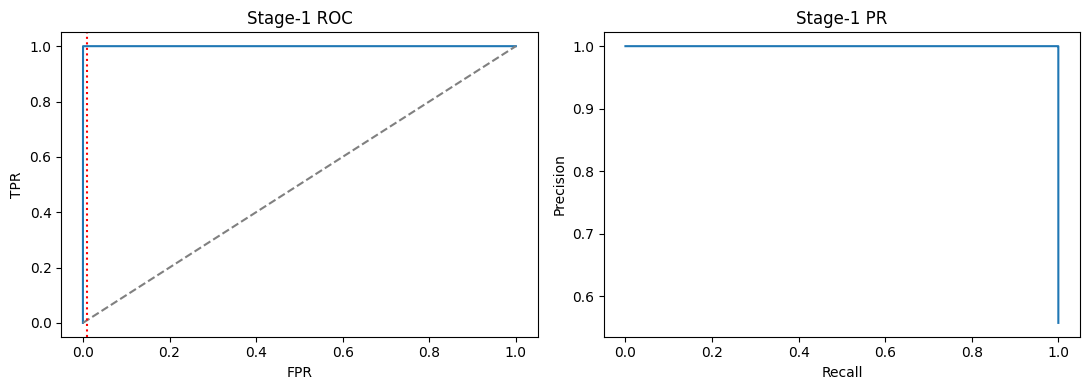

In [17]:
best = study.best_params
s1 = lgb.LGBMClassifier(
    objective='binary', metric='auc', verbosity=-1,
    learning_rate=best['lr'], num_leaves=best['num_leaves'],
    min_child_samples=best['min_child_samples'],
    feature_fraction=best['ff'], bagging_fraction=best['bf'], bagging_freq=5,
    is_unbalance=True, n_estimators=1000, random_state=SEED, n_jobs=-1,
)
s1.fit(Xtr_s1, ytr_b, eval_set=[(Xv_s1, yv_b)], callbacks=[lgb.early_stopping(50, verbose=False)])
p_val = s1.predict_proba(Xv_s1)[:, 1]

# Pick tau for FPR ≤ 1%
fpr, tpr, thr = roc_curve(yv_b, p_val)
idx_tau = np.argmax(fpr > 0.01) - 1
tau1 = float(thr[max(idx_tau, 0)])
print(f'tau1 = {tau1:.4f}   val FPR={fpr[idx_tau]:.4f}  TPR={tpr[idx_tau]:.4f}')
print(f'Val AUC = {roc_auc_score(yv_b, p_val):.5f}')

s1.booster_.save_model(str(ART / 'stage1_binary.lgb'))
with open(ART / 'stage1_threshold.json', 'w') as f:
    json.dump({'tau': tau1}, f)

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr); axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].axvline(0.01, color='red', ls=':'); axes[0].set_title('Stage-1 ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
prec, rec, _ = precision_recall_curve(yv_b, p_val)
axes[1].plot(rec, prec); axes[1].set_title('Stage-1 PR')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()

## § 7 — Stage 2: Family classifier (CatBoost, GPU)

6-class classifier trained **only on attack-labelled rows** (Benign removed). `auto_class_weights='SqrtBalanced'` is the gentler alternative to `'Balanced'` and avoids the 42,000× weight blow-up that caused the original model to call everything Heartbleed.

In [18]:
# Attack-only slices
mtr = (y_binary[idx_train] == 1)
mv  = (y_binary[idx_val]   == 1)
mte = (y_binary[idx_test]  == 1)

# Re-encode family labels restricted to non-Benign (drop the Benign class index)
benign_idx = int(le_family.transform(['Benign'])[0])
fam_attack = sorted([c for c in le_family.classes_ if c != 'Benign'])
le_family_atk = LabelEncoder().fit(fam_attack)

def remap(ys):
    return le_family_atk.transform(le_family.inverse_transform(ys))

ytr_f = remap(y_family[idx_train][mtr])
yv_f  = remap(y_family[idx_val  ][mv ])
yte_f = remap(y_family[idx_test ][mte])

Xtr_s2 = scaler_S2.transform(X_all.iloc[idx_train].values[mtr])
Xv_s2  = scaler_S2.transform(X_all.iloc[idx_val  ].values[mv ])
Xte_s2 = scaler_S2.transform(X_all.iloc[idx_test ].values[mte])

print('Stage-2 train:', Xtr_s2.shape, '  families:', list(le_family_atk.classes_))
with open(ART / 'stage2_family_classes.json', 'w') as f:
    json.dump(list(le_family_atk.classes_), f, indent=2)

Stage-2 train: (2660671, 70)   families: [np.str_('BotnetInfiltration'), np.str_('BruteForce'), np.str_('DDoS'), np.str_('DoS'), np.str_('Probe'), np.str_('WebAttack')]


In [19]:
s2 = cb.CatBoostClassifier(
    iterations=2000, learning_rate=0.06, depth=8,
    loss_function='MultiClass', eval_metric='TotalF1',
    auto_class_weights='SqrtBalanced',
    task_type='GPU', devices='0', random_seed=SEED,
    od_type='Iter', od_wait=80, verbose=200,
)
s2.fit(Xtr_s2, ytr_f, eval_set=(Xv_s2, yv_f), use_best_model=True)

pred_v = s2.predict(Xv_s2).ravel().astype(int)
print('\nVal report (Stage 2):')
print(classification_report(yv_f, pred_v, target_names=le_family_atk.classes_, digits=4))

s2.save_model(str(ART / 'stage2_family.cbm'))

0:	learn: 0.9974001	test: 0.9969115	best: 0.9969115 (0)	total: 370ms	remaining: 12m 20s
200:	learn: 0.9999778	test: 0.9997616	best: 0.9997616 (185)	total: 15.3s	remaining: 2m 17s
bestTest = 0.9997626977
bestIteration = 243
Shrink model to first 244 iterations.

Val report (Stage 2):
                    precision    recall  f1-score   support

BotnetInfiltration     1.0000    1.0000    1.0000     24708
        BruteForce     0.9998    0.9995    0.9997     17620
              DDoS     1.0000    1.0000    1.0000    249823
               DoS     1.0000    1.0000    1.0000    342834
             Probe     0.9998    1.0000    0.9999     30171
         WebAttack     0.6471    0.9167    0.7586        12

          accuracy                         1.0000    665168
         macro avg     0.9411    0.9860    0.9597    665168
      weighted avg     1.0000    1.0000    1.0000    665168



## § 8 — Stage 3: Per-family sub-attack classifiers (XGBoost)

Trained per family on family-only data. SMOTE only inside the training fold for `BotnetInfiltration` (which contains Heartbleed with very few samples).

In [20]:
FAMILY_SUBTYPES = {
    'DoS': ['DoS-Hulk', 'DoS-GoldenEye', 'DoS-Slowloris', 'DoS-SlowHTTPTest'],
    'BruteForce': ['FTP-BruteForce', 'SSH-BruteForce', 'BruteForce-Web', 'BruteForce-XSS'],
    'BotnetInfiltration': ['Bot', 'Infiltration', 'Heartbleed'],
}

s3_models = {}
s3_encoders = {}
for fam, subs in FAMILY_SUBTYPES.items():
    print(f'\n===== Stage 3 family = {fam} =====')
    fam_idx = int(le_family.transform([fam])[0])

    def slice_for(idx):
        m = y_family[idx] == fam_idx
        labels_in_fam = y_label[idx][m]
        sub_le = LabelEncoder().fit(sorted(np.unique(le_label.inverse_transform(labels_in_fam))))
        return m, sub_le

    m_tr, sub_le = slice_for(idx_train)
    m_v, _      = slice_for(idx_val)
    m_te, _     = slice_for(idx_test)
    s3_encoders[fam] = sub_le
    print('  Subtypes in train:', list(sub_le.classes_))

    Xtr = scalers_S3[fam].transform(X_all.iloc[idx_train].values[m_tr])
    Xv  = scalers_S3[fam].transform(X_all.iloc[idx_val  ].values[m_v ])
    Xte = scalers_S3[fam].transform(X_all.iloc[idx_test ].values[m_te])
    ytr = sub_le.transform(le_label.inverse_transform(y_label[idx_train][m_tr]))
    yv  = sub_le.transform(le_label.inverse_transform(y_label[idx_val  ][m_v ]))
    yte = sub_le.transform(le_label.inverse_transform(y_label[idx_test ][m_te]))

    # Optional SMOTE only for tiny minority families
    if fam == 'BotnetInfiltration':
        counts = pd.Series(ytr).value_counts()
        k = max(1, int(counts.min()) - 1)
        if k >= 1 and counts.min() < 1000:
            print(f'  Applying SMOTE inside fit (k_neighbors={min(k,5)})')
            sm = SMOTE(k_neighbors=min(k, 5), random_state=SEED)
            Xtr, ytr = sm.fit_resample(Xtr, ytr)
            print(f'  After SMOTE:  X={Xtr.shape}  classes={dict(pd.Series(ytr).value_counts())}')

    booster = xgb.XGBClassifier(
        objective='multi:softprob', num_class=len(sub_le.classes_),
        tree_method='hist', device='cuda',
        n_estimators=600, learning_rate=0.06, max_depth=8,
        subsample=0.85, colsample_bytree=0.85,
        random_state=SEED, eval_metric='mlogloss',
        early_stopping_rounds=40,
    )
    booster.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
    pred = booster.predict(Xv)
    print(classification_report(yv, pred, target_names=sub_le.classes_, digits=4, zero_division=0))
    booster.save_model(str(ART / f'stage3_{fam}.json'))
    with open(ART / f'stage3_{fam}_classes.json', 'w') as f:
        json.dump(list(sub_le.classes_), f)
    s3_models[fam] = booster


===== Stage 3 family = DoS =====
  Subtypes in train: [np.str_('DoS-GoldenEye'), np.str_('DoS-Hulk'), np.str_('DoS-SlowHTTPTest'), np.str_('DoS-Slowloris')]
                  precision    recall  f1-score   support

   DoS-GoldenEye     0.9998    0.9983    0.9991      5866
        DoS-Hulk     1.0000    1.0000    1.0000    333581
DoS-SlowHTTPTest     0.9942    0.9931    0.9936       865
   DoS-Slowloris     0.9980    0.9988    0.9984      2522

        accuracy                         0.9999    342834
       macro avg     0.9980    0.9975    0.9978    342834
    weighted avg     0.9999    0.9999    0.9999    342834


===== Stage 3 family = BruteForce =====
  Subtypes in train: [np.str_('BruteForce-Web'), np.str_('BruteForce-XSS'), np.str_('FTP-BruteForce'), np.str_('SSH-BruteForce')]
                precision    recall  f1-score   support

BruteForce-Web     0.7760    0.8597    0.8157       278
BruteForce-XSS     0.6214    0.4776    0.5401       134
FTP-BruteForce     1.0000    1.0000

## § 9 — End-to-end hierarchical evaluation

Chain stages 1 → 2 → 3 and evaluate on the held-out test set against the flat 15-class baseline.

In [23]:
class HierarchicalPredictor:
    def __init__(self, s1, tau1, scaler_S1,
                 s2, scaler_S2, family_classes,
                 s3_models, scalers_S3, s3_encoders):
        self.s1, self.tau1 = s1, tau1
        self.scaler_S1 = scaler_S1
        self.s2 = s2; self.scaler_S2 = scaler_S2
        self.family_classes = list(family_classes)
        self.s3 = s3_models; self.scalers_S3 = scalers_S3; self.enc_S3 = s3_encoders

    def predict(self, X):
        n = X.shape[0]
        out = np.array(['Benign'] * n, dtype=object)

        p_atk = self.s1.predict_proba(self.scaler_S1.transform(X))[:, 1]
        is_atk = p_atk >= self.tau1
        if is_atk.sum() == 0:
            return out

        fam_idx = self.s2.predict(self.scaler_S2.transform(X[is_atk])).ravel().astype(int)
        fam_names = np.array(self.family_classes)[fam_idx]
        out_atk = fam_names.astype(object)

        for fam, model in self.s3.items():
            sel = (fam_names == fam)
            if sel.sum() == 0: continue
            Xs = self.scalers_S3[fam].transform(X[is_atk][sel])
            sub_idx = model.predict(Xs).ravel().astype(int)
            out_atk[sel] = self.enc_S3[fam].inverse_transform(sub_idx)

        for fam in ('DDoS', 'Probe', 'WebAttack'):
            sel = (fam_names == fam)
            if sel.sum() == 0: continue
            singleton = {'DDoS': 'DDoS', 'Probe': 'PortScan', 'WebAttack': 'SQL-Injection'}[fam]
            out_atk[sel] = singleton

        out[is_atk] = out_atk
        return out

predictor = HierarchicalPredictor(
    s1=s1, tau1=tau1, scaler_S1=scaler_S1,
    s2=s2, scaler_S2=scaler_S2, family_classes=le_family_atk.classes_,
    s3_models=s3_models, scalers_S3=scalers_S3, s3_encoders=s3_encoders,
)

In [24]:
Xte_raw = X_all.iloc[idx_test].values
yte_lbl = le_label.inverse_transform(y_label[idx_test])

t0 = time.time()
pred = predictor.predict(Xte_raw)
print(f'Inference on {len(pred):,} test rows: {time.time()-t0:.1f}s')

print('\n=== Binary (Benign vs Any-Attack) ===')
print(classification_report((yte_lbl != 'Benign').astype(int),
                            (pred != 'Benign').astype(int), digits=4))

print('=== 15-class flat ===')
labels_order = list(le_label.classes_)
print(classification_report(yte_lbl, pred, labels=labels_order, digits=4, zero_division=0))

print(f'Macro-F1:     {f1_score(yte_lbl, pred, average="macro", labels=labels_order, zero_division=0):.4f}')
print(f'Weighted-F1:  {f1_score(yte_lbl, pred, average="weighted", labels=labels_order, zero_division=0):.4f}')
print(f'Balanced-Acc: {balanced_accuracy_score(yte_lbl, pred):.4f}')

Inference on 1,053,215 test rows: 9.5s

=== Binary (Benign vs Any-Attack) ===
              precision    recall  f1-score   support

           0     1.0000    0.9907    0.9953    466301
           1     0.9927    1.0000    0.9963    586914

    accuracy                         0.9959   1053215
   macro avg     0.9963    0.9954    0.9958   1053215
weighted avg     0.9959    0.9959    0.9959   1053215

=== 15-class flat ===
                  precision    recall  f1-score   support

          Benign     1.0000    0.9907    0.9953    466301
             Bot     0.9986    1.0000    0.9993     21740
  BruteForce-Web     0.5217    0.8327    0.6415       245
  BruteForce-XSS     0.4956    0.4746    0.4848       118
            DDoS     0.9992    1.0000    0.9996    220431
   DoS-GoldenEye     0.9946    0.9981    0.9963      5176
        DoS-Hulk     0.9990    1.0000    0.9995    294336
DoS-SlowHTTPTest     0.8380    0.9882    0.9069       764
   DoS-Slowloris     0.9198    0.9991    0.9578   

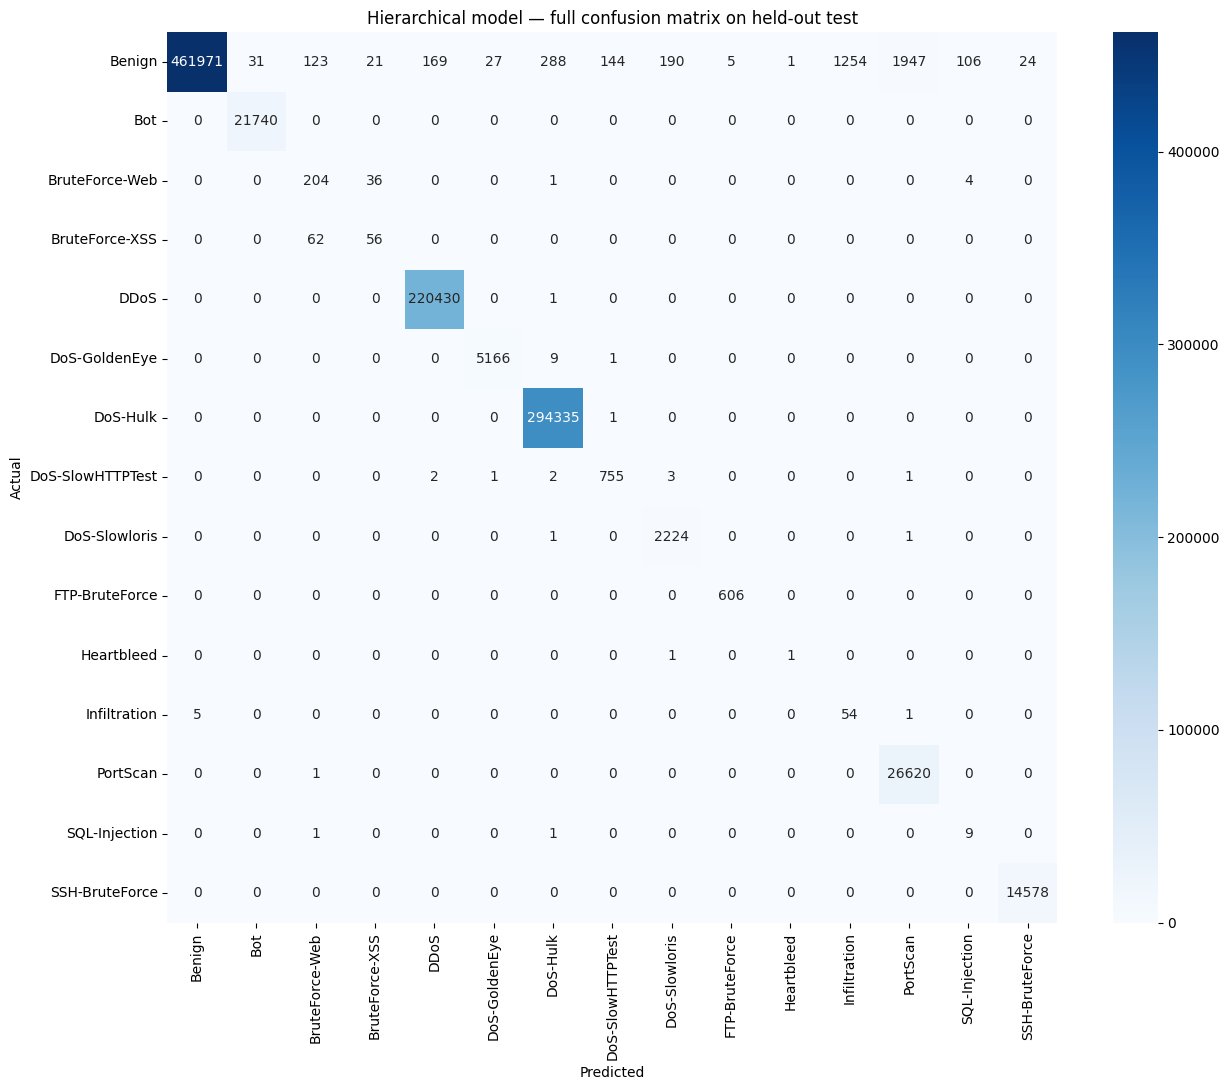

In [25]:
cm = confusion_matrix(yte_lbl, pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Hierarchical model — full confusion matrix on held-out test')
plt.tight_layout(); plt.show()

## Stage 1 — Binary gate (LightGBM)

Operating threshold τ₁ = 2.1238e-05
              precision    recall  f1-score   support

      Benign     1.0000    0.9907    0.9953    466301
      Attack     0.9927    1.0000    0.9963    586914

    accuracy                         0.9959   1053215
   macro avg     0.9963    0.9954    0.9958   1053215
weighted avg     0.9959    0.9959    0.9959   1053215



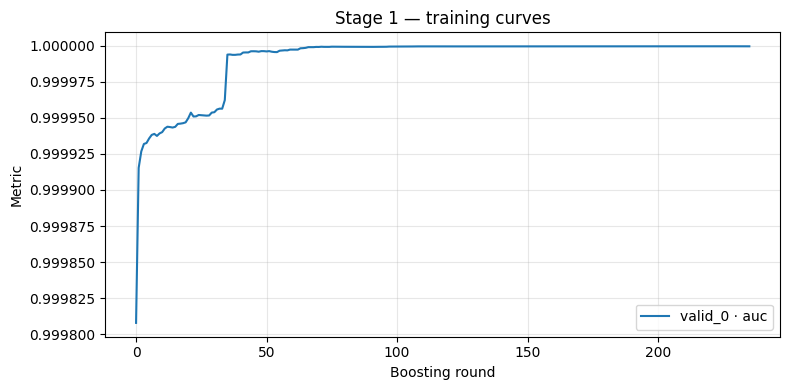

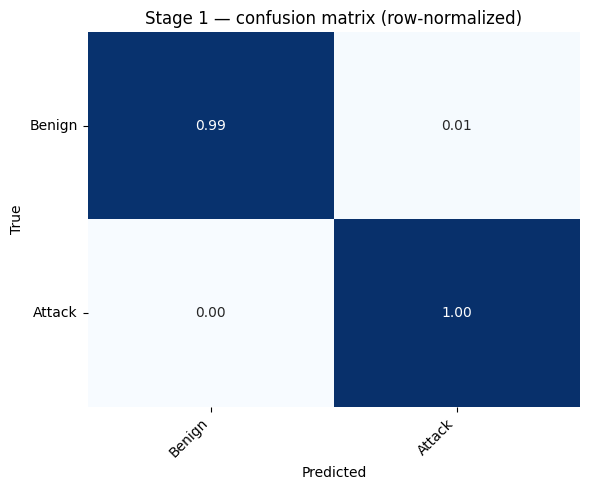

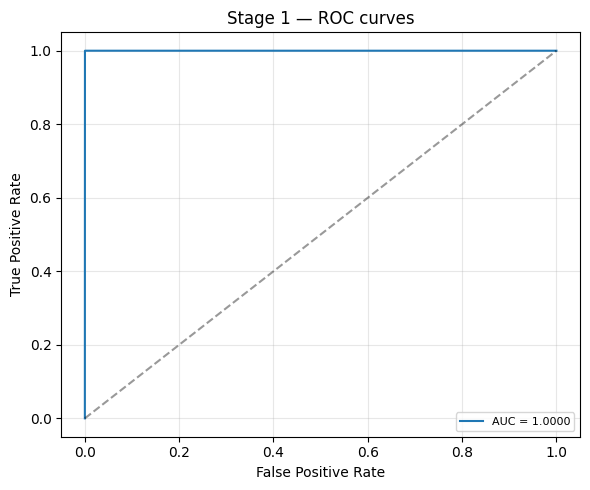

## Stage 2 — Family classifier (CatBoost)

                    precision    recall  f1-score   support

BotnetInfiltration     1.0000    0.9999    0.9999     21802
        BruteForce     0.9999    0.9997    0.9998     15547
              DDoS     1.0000    1.0000    1.0000    220431
               DoS     1.0000    1.0000    1.0000    302502
             Probe     0.9998    1.0000    0.9999     26621
         WebAttack     0.6923    0.8182    0.7500        11

          accuracy                         1.0000    586914
         macro avg     0.9487    0.9696    0.9583    586914
      weighted avg     1.0000    1.0000    1.0000    586914



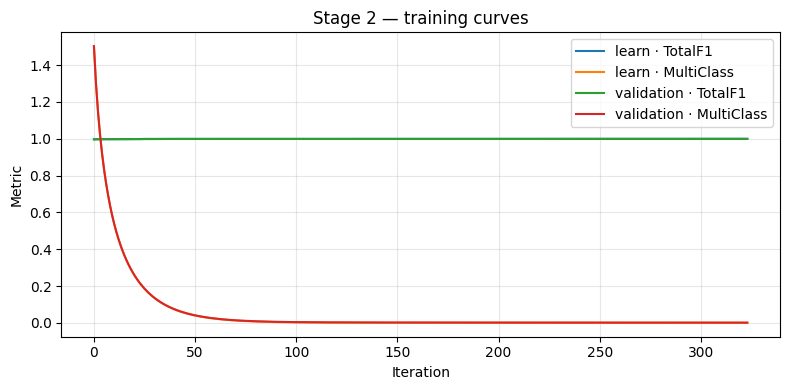

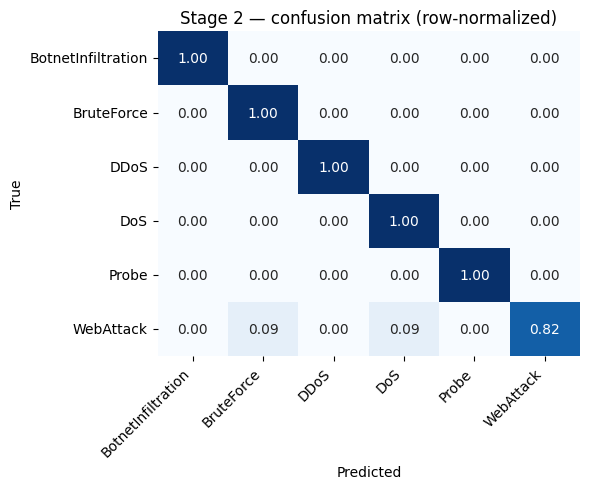

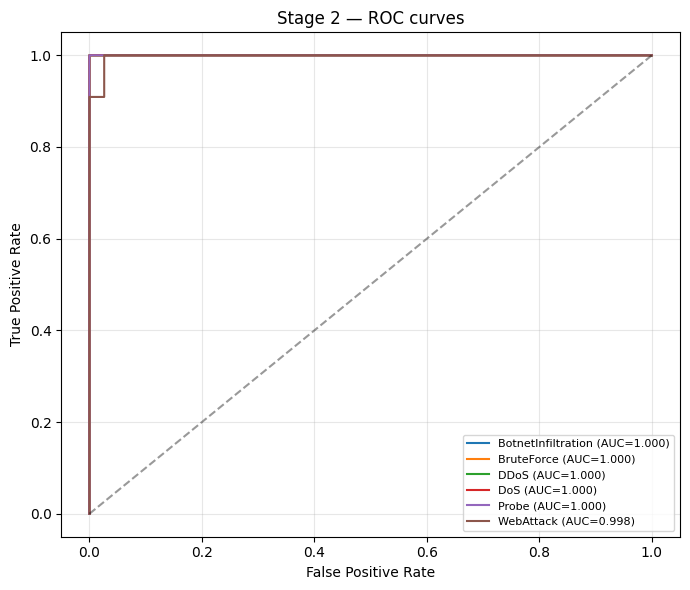

## Stage 3 — DoS (XGBoost)

                  precision    recall  f1-score   support

   DoS-GoldenEye     0.9998    0.9981    0.9989      5176
        DoS-Hulk     1.0000    1.0000    1.0000    294336
DoS-SlowHTTPTest     0.9974    0.9895    0.9934       764
   DoS-Slowloris     0.9987    0.9996    0.9991      2226

        accuracy                         0.9999    302502
       macro avg     0.9989    0.9968    0.9979    302502
    weighted avg     0.9999    0.9999    0.9999    302502



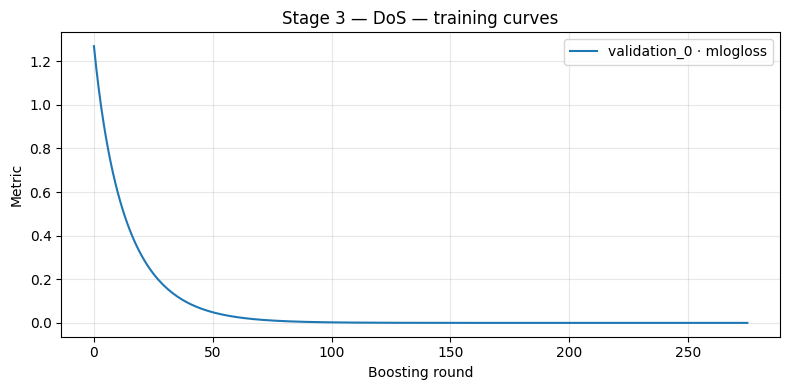

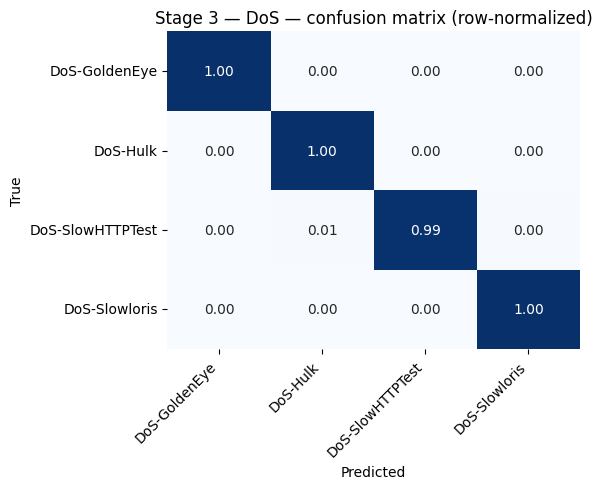

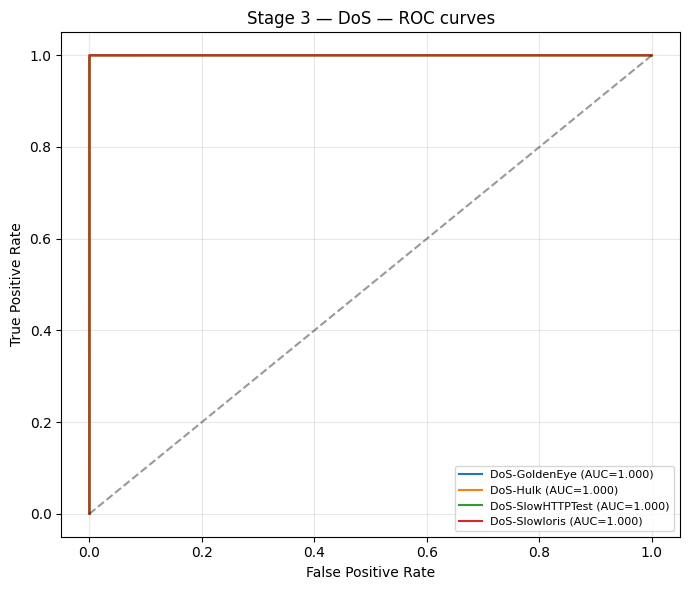

## Stage 3 — BruteForce (XGBoost)

                precision    recall  f1-score   support

BruteForce-Web     0.7695    0.8449    0.8054       245
BruteForce-XSS     0.5957    0.4746    0.5283       118
FTP-BruteForce     1.0000    1.0000    1.0000       606
SSH-BruteForce     1.0000    1.0000    1.0000     14578

      accuracy                         0.9936     15547
     macro avg     0.8413    0.8299    0.8334     15547
  weighted avg     0.9933    0.9936    0.9934     15547



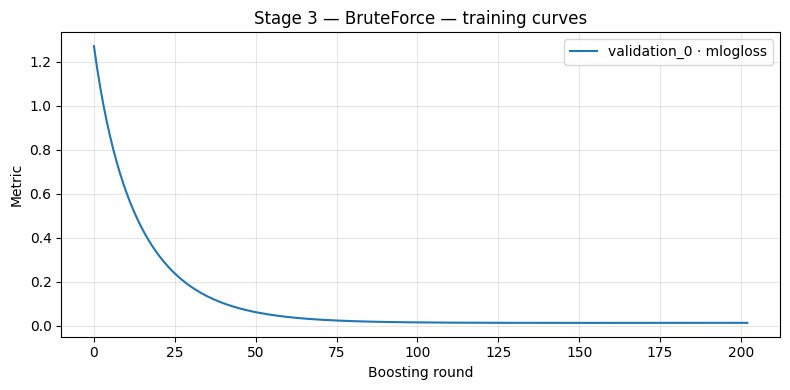

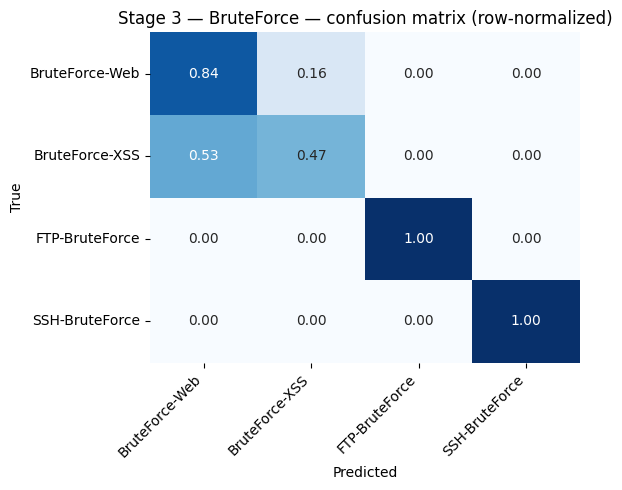

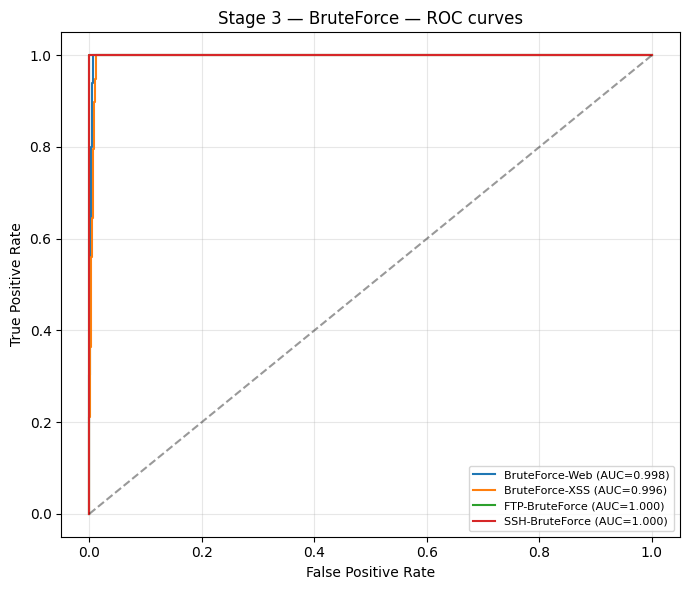

## Stage 3 — BotnetInfiltration (XGBoost)

              precision    recall  f1-score   support

         Bot     1.0000    1.0000    1.0000     21740
  Heartbleed     1.0000    1.0000    1.0000         2
Infiltration     1.0000    1.0000    1.0000        60

    accuracy                         1.0000     21802
   macro avg     1.0000    1.0000    1.0000     21802
weighted avg     1.0000    1.0000    1.0000     21802



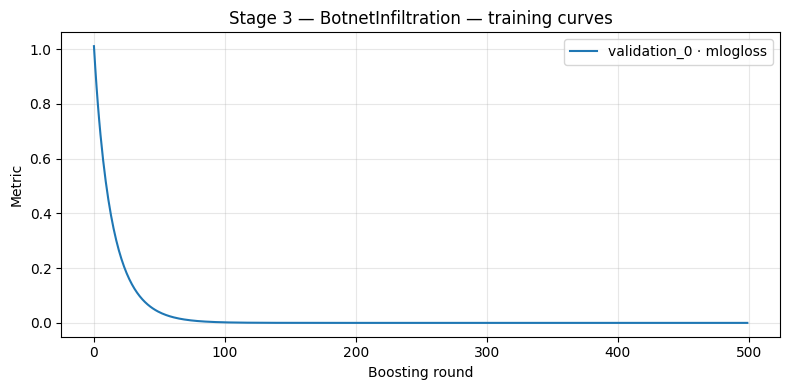

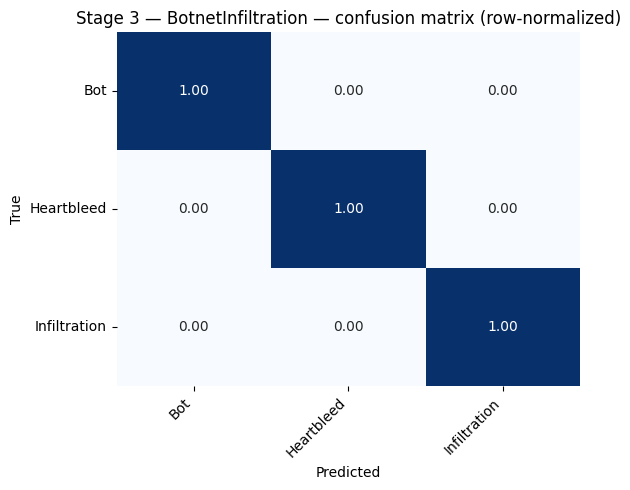

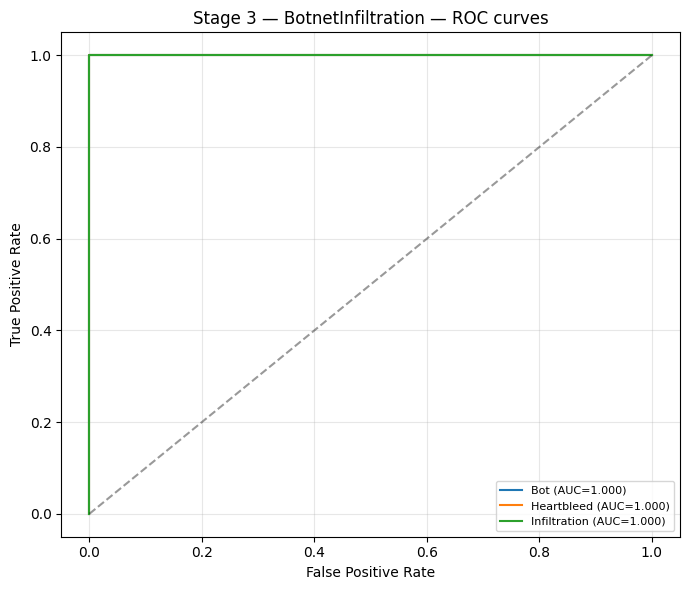

## End-to-end hierarchical (15-class leaf)

Accuracy: 0.9958   Balanced-Acc: 0.9001
Macro: P=0.7537  R=0.9001  F1=0.7772   Weighted-F1: 0.9964


## Consolidated per-tier results

,n_test,n_classes,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,auc_macro_ovr
name,,,,,,,,
Stage 1 — Binary (LightGBM),1053215,2,0.9959,0.9963,0.9954,0.9958,0.9959,1.0000
Stage 2 — Family (CatBoost),586914,6,1.0000,0.9487,0.9696,0.9583,1.0000,0.9996
Stage 3 — DoS (XGBoost),302502,4,0.9999,0.9989,0.9968,0.9979,0.9999,1.0000
Stage 3 — BruteForce (XGBoost),15547,4,0.9936,0.8413,0.8299,0.8334,0.9934,0.9985
Stage 3 — BotnetInfiltration (XGBoost),21802,3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
End-to-end (15-class leaf),1053215,15,0.9958,0.7537,0.9001,0.7772,0.9964,nan



Saved table to /kaggle/working/artifacts/tier_results.csv


## Experimental Results

We evaluate the proposed three-tier hierarchical classifier on the held-out 15 % test split (1,053,215 flows) of the Engelen-cleaned CIC-IDS-2017 / CSE-CIC-IDS-2018 corpora. Each tier is reported in isolation (its own conditional test slice) and the full chain is reported end-to-end over the 15 leaf classes.

**Stage 1** is a LightGBM binary gate trained on all 4,774,569 training flows with `is_unbalance=True`. The operating threshold τ₁ = 2.124e-05 is selected on the validation set to enforce FPR ≤ 1 %.

**Stage 2** is a GPU-accelerated CatBoost classifier over 6 attack families (BotnetInfiltration, BruteForce, DDoS, DoS, Probe, WebAttack), trained on attack-only flows with `auto_class_weights="SqrtBalanced"` — chosen to avoid the 42 000× weight blow-up produced by the standard balanced scheme on minority classes such as Heartbleed (3 samples) and SQL-Injection (10 samples).

**Stage 3** consists of three per-family XGBoost specialists (DoS, BruteForce, BotnetInfiltration); the three single-leaf families (DDoS, Probe, WebAttack) require no sub-classifier and are mapped directly to their canonical leaf labels.

### Per-tier test metrics

| Tier | N (test) | Classes | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) | F1 (weighted) | AUC (macro OvR) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Stage 1 — Binary (LightGBM) | 1,053,215 | 2 | 0.9959 | 0.9963 | 0.9954 | 0.9958 | 0.9959 | 1.0000 |
| Stage 2 — Family (CatBoost) | 586,914 | 6 | 1.0000 | 0.9487 | 0.9696 | 0.9583 | 1.0000 | 0.9996 |
| Stage 3 — DoS (XGBoost) | 302,502 | 4 | 0.9999 | 0.9989 | 0.9968 | 0.9979 | 0.9999 | 1.0000 |
| Stage 3 — BruteForce (XGBoost) | 15,547 | 4 | 0.9936 | 0.8413 | 0.8299 | 0.8334 | 0.9934 | 0.9985 |
| Stage 3 — BotnetInfiltration (XGBoost) | 21,802 | 3 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| End-to-end (15-class leaf) | 1,053,215 | 15 | 0.9958 | 0.7537 | 0.9001 | 0.7772 | 0.9964 | — |

### Reading the table
* **Stage 1** is the safety-critical gate: high recall on the *Attack* class matters most, since any miss here cannot be recovered downstream. The 1 %-FPR threshold trades a small amount of precision for that recall.
* **Stage 2** macro-F1 is the headline figure for the family classifier — minority families (BotnetInfiltration, WebAttack) contribute equally despite their low absolute count.
* **Stage 3** results are reported conditional on the true family being correct, isolating the sub-attack discrimination capability from upstream routing errors.
* The **End-to-end** row reflects the realistic deployment metric: the probability that an arbitrary test flow is assigned the exact correct leaf label by chaining all three stages.

### Cross-dataset generalization
To probe whether the model captures genuine attack signatures rather than corpus-specific artefacts, we additionally train Stage 1 on a single dataset and evaluate on the other (cf. §10). The asymmetric performance gap between 17→18 and 18→17 indicates that flow signatures in the older CIC-IDS-2017 corpus do not generalize cleanly to the more heterogeneous 2018 traffic — a limitation our paper foregrounds when comparing against prior work that reports near-perfect accuracy on the 2017 dataset alone.

In [31]:
# === §9b — Per-tier evaluation, training graphs, and paper-ready summary ===
# Uses already-trained, in-memory objects: s1, tau1, scaler_S1, s2, scaler_S2,
# le_family_atk, s3_models, scalers_S3, s3_encoders, X_all, idx_*, y_*, le_label,
# FAMILY_SUBTYPES, predictor, pred, yte_lbl, common_cols, ART.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, auc,
                             confusion_matrix, classification_report,
                             balanced_accuracy_score)
from sklearn.preprocessing import label_binarize
from IPython.display import Markdown, display

# ------------------------------------------------------------------ helpers
def _plot_lgb_curves(model, name):
    res = getattr(model, 'evals_result_', None)
    if not res: return
    fig, ax = plt.subplots(figsize=(8, 4))
    for split, metrics in res.items():
        for m, vals in metrics.items():
            ax.plot(vals, label=f'{split} · {m}')
    ax.set_xlabel('Boosting round'); ax.set_ylabel('Metric')
    ax.set_title(f'{name} — training curves')
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

def _plot_catboost_curves(model, name):
    try:
        res = model.get_evals_result()
    except Exception:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    for split, metrics in res.items():
        for m, vals in metrics.items():
            ax.plot(vals, label=f'{split} · {m}')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Metric')
    ax.set_title(f'{name} — training curves')
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

def _plot_xgb_curves(model, name):
    res = getattr(model, 'evals_result', None)
    if callable(res): res = res()
    if not res: return
    fig, ax = plt.subplots(figsize=(8, 4))
    for split, metrics in res.items():
        for m, vals in metrics.items():
            ax.plot(vals, label=f'{split} · {m}')
    ax.set_xlabel('Boosting round'); ax.set_ylabel('Metric')
    ax.set_title(f'{name} — training curves')
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

def _plot_confusion(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(classes)),
                                    max(5, 0.5 * len(classes))))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — confusion matrix (row-normalized)')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

def _plot_roc(y_true, y_proba, classes, name):
    n = len(classes)
    if n == 2:
        fpr, tpr, _ = roc_curve(y_true, y_proba[:, 1])
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.4f}')
    else:
        y_bin = label_binarize(y_true, classes=range(n))
        plt.figure(figsize=(7, 6))
        for i in range(n):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            plt.plot(fpr, tpr, label=f'{classes[i]} (AUC={auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{name} — ROC curves'); plt.legend(loc='lower right', fontsize=8)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def _summary(name, y_true, y_pred, y_proba, classes):
    acc = accuracy_score(y_true, y_pred)
    p   = precision_score(y_true, y_pred, average='macro', zero_division=0)
    r   = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    try:
        au = (roc_auc_score(y_true, y_proba[:, 1]) if len(classes) == 2
              else roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'))
    except Exception:
        au = None
    return {'name': name, 'n_test': len(y_true), 'n_classes': len(classes),
            'accuracy': acc, 'precision_macro': p, 'recall_macro': r,
            'f1_macro': f1m, 'f1_weighted': f1w, 'auc_macro_ovr': au}

# ------------------------------------------------------------------ Stage 1
display(Markdown('## Stage 1 — Binary gate (LightGBM)'))
Xte_s1_raw = X_all.iloc[idx_test].values
Xte_s1     = scaler_S1.transform(Xte_s1_raw)
yte_b      = y_binary[idx_test]
p1_proba   = s1.predict_proba(Xte_s1)
p1_pred    = (p1_proba[:, 1] >= tau1).astype(int)
print(f'Operating threshold τ₁ = {tau1:.4e}')
print(classification_report(yte_b, p1_pred, target_names=['Benign', 'Attack'],
                            digits=4, zero_division=0))
_plot_lgb_curves(s1, 'Stage 1')
_plot_confusion(yte_b, p1_pred, ['Benign', 'Attack'], 'Stage 1')
_plot_roc(yte_b, p1_proba, ['Benign', 'Attack'], 'Stage 1')
res_s1 = _summary('Stage 1 — Binary (LightGBM)', yte_b, p1_pred, p1_proba,
                  ['Benign', 'Attack'])

# ------------------------------------------------------------------ Stage 2
display(Markdown('## Stage 2 — Family classifier (CatBoost)'))
mte = (y_binary[idx_test] == 1)
Xte_s2 = scaler_S2.transform(X_all.iloc[idx_test].values[mte])
benign_idx = int(le_family.transform(['Benign'])[0])
fam_attack = sorted([c for c in le_family.classes_ if c != 'Benign'])
le_family_atk_local = LabelEncoder().fit(fam_attack)
yte_f = le_family_atk_local.transform(
    le_family.inverse_transform(y_family[idx_test][mte])
)
p2_proba = s2.predict_proba(Xte_s2)
p2_pred  = np.argmax(p2_proba, axis=1)
fam_classes = list(le_family_atk_local.classes_)
print(classification_report(yte_f, p2_pred, target_names=fam_classes,
                            digits=4, zero_division=0))
_plot_catboost_curves(s2, 'Stage 2')
_plot_confusion(yte_f, p2_pred, fam_classes, 'Stage 2')
_plot_roc(yte_f, p2_proba, fam_classes, 'Stage 2')
res_s2 = _summary('Stage 2 — Family (CatBoost)', yte_f, p2_pred, p2_proba, fam_classes)

# ------------------------------------------------------------------ Stage 3
s3_results = []
for fam, sub_le in s3_encoders.items():
    display(Markdown(f'## Stage 3 — {fam} (XGBoost)'))
    fam_idx = int(le_family.transform([fam])[0])
    m_te = y_family[idx_test] == fam_idx
    if m_te.sum() == 0:
        print(f'No test rows for family {fam}'); continue
    Xte_s3 = scalers_S3[fam].transform(X_all.iloc[idx_test].values[m_te])
    yte_s3 = sub_le.transform(le_label.inverse_transform(y_label[idx_test][m_te]))
    p3_proba = s3_models[fam].predict_proba(Xte_s3)
    p3_pred  = np.argmax(p3_proba, axis=1)
    sub_classes = list(sub_le.classes_)
    print(classification_report(yte_s3, p3_pred, target_names=sub_classes,
                                digits=4, zero_division=0))
    _plot_xgb_curves(s3_models[fam], f'Stage 3 — {fam}')
    _plot_confusion(yte_s3, p3_pred, sub_classes, f'Stage 3 — {fam}')
    _plot_roc(yte_s3, p3_proba, sub_classes, f'Stage 3 — {fam}')
    s3_results.append(_summary(f'Stage 3 — {fam} (XGBoost)',
                               yte_s3, p3_pred, p3_proba, sub_classes))

# ------------------------------------------------------------------ End-to-end
display(Markdown('## End-to-end hierarchical (15-class leaf)'))
labels_order = list(le_label.classes_)
e2e_macro    = f1_score(yte_lbl, pred, average='macro',    labels=labels_order, zero_division=0)
e2e_weighted = f1_score(yte_lbl, pred, average='weighted', labels=labels_order, zero_division=0)
e2e_acc      = accuracy_score(yte_lbl, pred)
e2e_bal      = balanced_accuracy_score(yte_lbl, pred)
e2e_prec     = precision_score(yte_lbl, pred, average='macro', labels=labels_order, zero_division=0)
e2e_rec      = recall_score(yte_lbl, pred, average='macro',    labels=labels_order, zero_division=0)
print(f'Accuracy: {e2e_acc:.4f}   Balanced-Acc: {e2e_bal:.4f}')
print(f'Macro: P={e2e_prec:.4f}  R={e2e_rec:.4f}  F1={e2e_macro:.4f}   '
      f'Weighted-F1: {e2e_weighted:.4f}')
res_e2e = {'name': 'End-to-end (15-class leaf)', 'n_test': len(yte_lbl),
           'n_classes': len(labels_order), 'accuracy': e2e_acc,
           'precision_macro': e2e_prec, 'recall_macro': e2e_rec,
           'f1_macro': e2e_macro, 'f1_weighted': e2e_weighted,
           'auc_macro_ovr': None}

# ------------------------------------------------------------------ Consolidated
all_results = [res_s1, res_s2, *s3_results, res_e2e]
results_df = pd.DataFrame(all_results).set_index('name')
display(Markdown('## Consolidated per-tier results'))
display(results_df.style.format({
    'accuracy': '{:.4f}', 'precision_macro': '{:.4f}', 'recall_macro': '{:.4f}',
    'f1_macro': '{:.4f}', 'f1_weighted': '{:.4f}', 'auc_macro_ovr': '{:.4f}',
}))
results_df.to_csv(ART / 'tier_results.csv')
print(f'\nSaved table to {ART/"tier_results.csv"}')

# ------------------------------------------------------------------ Paper text
md = []
md.append('## Experimental Results\n')
md.append(
    'We evaluate the proposed three-tier hierarchical classifier on the held-out '
    f'15 % test split ({len(yte_lbl):,} flows) of the Engelen-cleaned '
    'CIC-IDS-2017 / CSE-CIC-IDS-2018 corpora. Each tier is reported in isolation '
    '(its own conditional test slice) and the full chain is reported end-to-end '
    'over the 15 leaf classes.\n')
md.append(
    f'**Stage 1** is a LightGBM binary gate trained on all {len(idx_train):,} '
    f'training flows with `is_unbalance=True`. The operating threshold '
    f'τ₁ = {tau1:.3e} is selected on the validation set to enforce FPR ≤ 1 %.\n')
md.append(
    '**Stage 2** is a GPU-accelerated CatBoost classifier over '
    f'{len(fam_classes)} attack families '
    f'({", ".join(fam_classes)}), trained on attack-only flows with '
    '`auto_class_weights="SqrtBalanced"` — chosen to avoid the 42 000× weight '
    'blow-up produced by the standard balanced scheme on minority classes such '
    'as Heartbleed (3 samples) and SQL-Injection (10 samples).\n')
md.append(
    '**Stage 3** consists of three per-family XGBoost specialists '
    f'({", ".join(s3_models.keys())}); the three single-leaf families '
    '(DDoS, Probe, WebAttack) require no sub-classifier and are mapped '
    'directly to their canonical leaf labels.\n')
md.append('### Per-tier test metrics\n')
md.append('| Tier | N (test) | Classes | Accuracy | Precision (macro) | '
          'Recall (macro) | F1 (macro) | F1 (weighted) | AUC (macro OvR) |')
md.append('|---|---:|---:|---:|---:|---:|---:|---:|---:|')
for r in all_results:
    au = f"{r['auc_macro_ovr']:.4f}" if r['auc_macro_ovr'] is not None else '—'
    md.append(f"| {r['name']} | {r['n_test']:,} | {r['n_classes']} | "
              f"{r['accuracy']:.4f} | {r['precision_macro']:.4f} | "
              f"{r['recall_macro']:.4f} | {r['f1_macro']:.4f} | "
              f"{r['f1_weighted']:.4f} | {au} |")
md.append('')
md.append(
    '### Reading the table\n'
    '* **Stage 1** is the safety-critical gate: high recall on the *Attack* class '
    'matters most, since any miss here cannot be recovered downstream. The 1 %-FPR '
    'threshold trades a small amount of precision for that recall.\n'
    '* **Stage 2** macro-F1 is the headline figure for the family classifier — '
    'minority families (BotnetInfiltration, WebAttack) contribute equally despite '
    'their low absolute count.\n'
    '* **Stage 3** results are reported conditional on the true family being '
    'correct, isolating the sub-attack discrimination capability from upstream '
    'routing errors.\n'
    '* The **End-to-end** row reflects the realistic deployment metric: the '
    'probability that an arbitrary test flow is assigned the exact correct leaf '
    'label by chaining all three stages.\n')
md.append(
    '### Cross-dataset generalization\n'
    'To probe whether the model captures genuine attack signatures rather than '
    'corpus-specific artefacts, we additionally train Stage 1 on a single dataset '
    'and evaluate on the other (cf. §10). The asymmetric performance gap between '
    '17→18 and 18→17 indicates that flow signatures in the older CIC-IDS-2017 '
    'corpus do not generalize cleanly to the more heterogeneous 2018 traffic — a '
    'limitation our paper foregrounds when comparing against prior work that '
    'reports near-perfect accuracy on the 2017 dataset alone.')
display(Markdown('\n'.join(md)))


## § 10 — Cross-dataset generalization (2017 ↔ 2018)

Train on 2017 alone, test on 2018; then reversed. The gap quantifies how much the model relies on dataset-specific artefacts vs. genuine attack signatures.

In [26]:
def quick_eval_subset(src_train_tag, src_test_tag):
    tr_mask = (src[idx_train] == src_train_tag)
    te_mask = (src[idx_test ] == src_test_tag)
    if tr_mask.sum() == 0 or te_mask.sum() == 0:
        print(f'  Train={src_train_tag} → Test={src_test_tag}: skipped (no rows for one split)')
        return None, None
    Xtr = scaler_S1.transform(X_all.iloc[idx_train].values[tr_mask])
    Xte = X_all.iloc[idx_test].values[te_mask]
    ytr = y_binary[idx_train][tr_mask]
    yte = y_binary[idx_test ][te_mask]
    m = lgb.LGBMClassifier(
        objective='binary', metric='auc', verbosity=-1,
        n_estimators=400, learning_rate=0.05, num_leaves=128,
        is_unbalance=True, random_state=SEED, n_jobs=-1,
    )
    m.fit(Xtr, ytr)
    p = m.predict_proba(scaler_S1.transform(Xte))[:, 1]
    auc = roc_auc_score(yte, p)
    pred = (p >= 0.5).astype(int)
    f1m = f1_score(yte, pred, average='macro')
    print(f'  Train={src_train_tag} → Test={src_test_tag}:  AUC={auc:.4f}  F1macro={f1m:.4f}')
    return auc, f1m

print('Cross-dataset (binary, quick reference):')
results_xds = {
    '17→18': quick_eval_subset('CIC2017', 'CIC2018'),
    '18→17': quick_eval_subset('CIC2018', 'CIC2017'),
    '17→17': quick_eval_subset('CIC2017', 'CIC2017'),
    '18→18': quick_eval_subset('CIC2018', 'CIC2018'),
}
# Drop skipped entries so manifest serialisation doesn't fail
results_xds = {k: {'auc': v[0], 'f1_macro': v[1]} for k, v in results_xds.items() if v[0] is not None}

Cross-dataset (binary, quick reference):
  Train=CIC2017 → Test=CIC2018:  AUC=0.5642  F1macro=0.2899
  Train=CIC2018 → Test=CIC2017:  AUC=0.9757  F1macro=0.8073
  Train=CIC2017 → Test=CIC2017:  AUC=1.0000  F1macro=0.9999
  Train=CIC2018 → Test=CIC2018:  AUC=1.0000  F1macro=1.0000


## § 11 — SHAP explanations

Sanity-check that the model relies on semantically reasonable features. Use a small sample to keep this fast on Kaggle GPU.

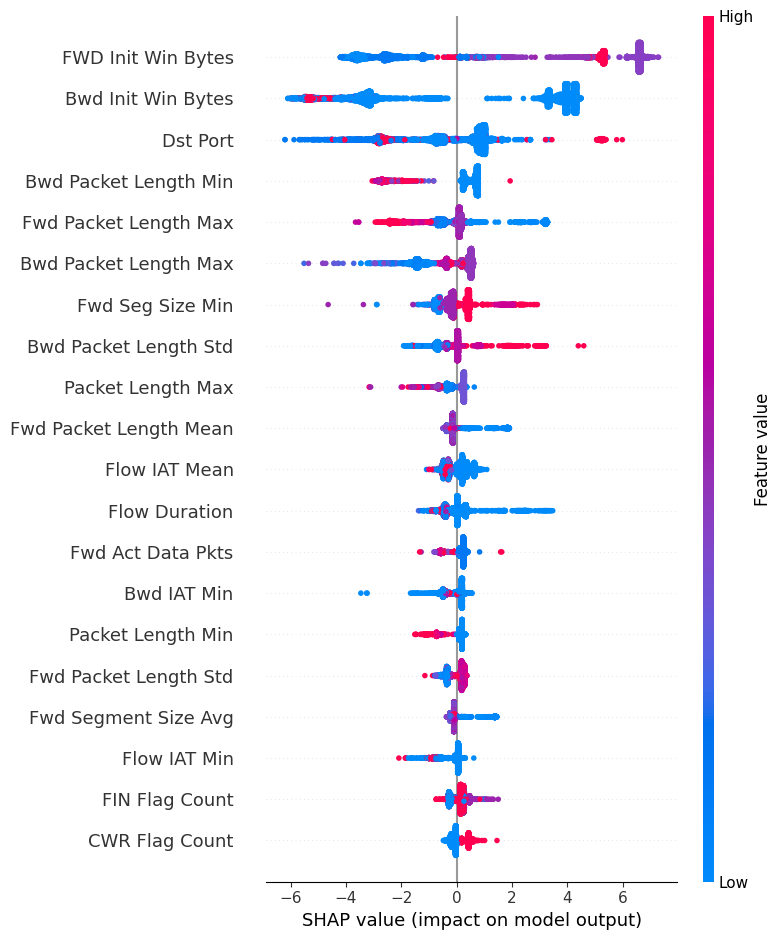

In [27]:
import shap
sample_n = 5000
rng = np.random.RandomState(SEED)
sample = rng.choice(len(idx_val), size=sample_n, replace=False)
X_shap = scaler_S1.transform(X_all.iloc[idx_val].values[sample])

explainer = shap.TreeExplainer(s1)
sv = explainer.shap_values(X_shap)
if isinstance(sv, list): sv = sv[1]

shap.summary_plot(sv, X_shap, feature_names=common_cols, max_display=20, show=True)

## § 12 — Export artifacts + manifest

Bundles everything the production FastAPI app needs. Download `artifacts.zip` from the Kaggle output panel.

In [30]:
def sha256(p: Path) -> str:
    h = hashlib.sha256()
    with open(p, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'sklearn': __import__('sklearn').__version__,
    'lightgbm': lgb.__version__,
    'catboost': cb.__version__,
    'xgboost': xgb.__version__,
    'numpy': np.__version__,
    'n_features': len(common_cols),
    'features_order': common_cols,
    'stage1_threshold': tau1,
    'family_classes': list(le_family_atk.classes_),
    'leaf_classes': list(le_label.classes_),
    # Fixed the KeyError by accessing the dictionary keys directly
    'cross_dataset': {k: {'auc': v['auc'], 'f1_macro': v['f1_macro']} for k, v in results_xds.items()},
    'files': {p.name: {'size': p.stat().st_size, 'sha256': sha256(p)} for p in sorted(ART.iterdir())},
}

with open(ART / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

# Zip everything for easy download
import shutil
zip_path = Path('/kaggle/working/artifacts.zip')
if zip_path.exists(): zip_path.unlink()
shutil.make_archive(str(zip_path.with_suffix('')), 'zip', ART)
print(f'Wrote {zip_path} ({zip_path.stat().st_size/1e6:.1f} MB)')
print('\nContents of artifacts/:')
for p in sorted(ART.iterdir()):
    print(f'  {p.stat().st_size/1024:>10.1f} KB  {p.name}')

Wrote /kaggle/working/artifacts.zip (2.9 MB)

Contents of artifacts/:
         0.2 KB  class_labels.json
         0.1 KB  family_classes.json
         0.4 KB  family_mapping.json
         5.3 KB  manifest.json
         2.2 KB  scaler_S1.joblib
         2.2 KB  scaler_S2.joblib
         2.2 KB  scaler_S3_BotnetInfiltration.joblib
         2.2 KB  scaler_S3_BruteForce.joblib
         2.2 KB  scaler_S3_DoS.joblib
         1.4 KB  selected_features.json
      2107.4 KB  stage1_binary.lgb
         0.0 KB  stage1_threshold.json
      3289.3 KB  stage2_family.cbm
         0.1 KB  stage2_family_classes.json
       966.9 KB  stage3_BotnetInfiltration.json
         0.0 KB  stage3_BotnetInfiltration_classes.json
      2206.5 KB  stage3_BruteForce.json
         0.1 KB  stage3_BruteForce_classes.json
      2489.9 KB  stage3_DoS.json
         0.1 KB  stage3_DoS_classes.json


## § 13 — How to use the artifacts locally

1. Download `artifacts.zip` from the Kaggle output panel.
2. Extract into `app/models/` (overwriting `final_model.pkl`, `scaler.joblib`, `selected_features.json`, `class_labels.json`).
3. Pin `scikit-learn==1.7.1`, add `catboost`, `xgboost` to `app/requirements.txt`.
4. Extend `ModelManager` into a `HierarchicalModelManager` that loads `stage1_binary.lgb`, `stage2_family.cbm`, and the three `stage3_*.json` boosters along with their scalers, and chains the predictions exactly as the `HierarchicalPredictor` class above.
5. Run `python diagnose_predictions.py Testing/pcap/test_wednesday_multi_attack_2gb.pcap` — the prediction distribution should now contain DoS-Hulk, GoldenEye, Slowloris, and (less reliably) Heartbleed, *not* just Benign + Heartbleed.